<div style="
  width:100%;
  border-radius:18px;
  padding:26px 28px;
  text-align:center;
  background:linear-gradient(135deg,#f8fafc 0%, #f1f5f9 50%, #ffffff 100%);
  border:1px solid rgba(55,65,81,0.18);
  font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Inter,Arial,sans-serif;
">

<div style="
  display:inline-block;
  padding:6px 14px;
  border-radius:999px;
  border:1px solid rgba(15,23,42,0.18);
  background:rgba(255,255,255,0.9);
  font-size:12px;
  font-weight:700;
  color:rgba(15,23,42,0.7);
  margin-bottom:14px;
">
Decision-Support Analytics • Marketplace Intelligence
</div>

<div style="
  font-size:32px;
  font-weight:900;
  line-height:1.15;
  margin-bottom:10px;
">
  <span style="color:#FBBF24;">Amazon</span>
  <span style="color:#64748B;"> — </span>
  <span style="color:#0f172a;">Governance</span>
  <span style="color:#64748B;"> &times; </span>
  <span style="color:#92400E;">Risk</span>
  <span style="color:#64748B;"> &times; </span>
  <span style="color:#0f172a;">Discovery</span>
</div>

<div style="
  font-size:15px;
  font-weight:600;
  color:rgba(15,23,42,0.65);
">
Typed INR Pricing • Discount Integrity • Satisfaction Signals • Discovery Baselines
</div>

![Amazon Governance Risk Discovery](https://raw.githubusercontent.com/rbyzk/MachineLearningProjects/9df8318c6e19b0e37536fb93866b58038ccf6245/Amazon_Governance_Risk_Discovery/Amazon.png)

## Introduction — Turning Raw Amazon Data into Decision-Grade Insights

In high-volume marketplaces like Amazon, having “a lot of data” is not the advantage by itself. The advantage comes from making the data **trusted (governed), comparable (typed), and action-oriented (decision-grade)**.

This notebook is built from that premise. I take a raw Amazon dataset and turn key signals—prices in ₹ (INR), discounts in %, ratings, vote counts, and review text—into an executive-ready framework that combines **Governance + Risk + Recommendations** in one coherent flow.

---

### Governance: accuracy, typing, and integrity controls
Before I run any EDA or modeling, I focus on ensuring the dataset is analytically credible. In this dataset, core fields often arrive as `object` strings (₹, commas, %, mixed formats), which can quietly break analysis.

To prevent that, I:
- Parse **INR prices (₹)** into numeric values (handling commas and stray characters),
- Parse **discount percentages (%)** into numeric values and validate the scale (0–100),
- Normalize **rating** and **rating_count** into numeric types,
- Add a **discount consistency control** by comparing stated discount % vs recalculated discount % from prices,
- Expand **category** into a shallow taxonomy (**L1–L3**) to enable segmentation without creating an unreadable schema,
- Treat multi-value fields (e.g., `user_id`) with a governance lens by computing only **counts** (observability), rather than materializing noisy list features.

Goal: ensure all downstream charts and models are built on **clean signal**, not formatting artifacts.

---

### Risk: an interpretable “Satisfaction Risk” classification lens
Once the dataset is governed, I translate “rating performance” into a simple operational risk framing:

- I define **`at_risk = 1`** when `rating < 4.0`
- I apply a minimum engagement gate (**votes ≥ 50**) to avoid acting on statistically weak signals

Then I benchmark multiple modeling tracks to support decision-grade comparison:
- **Text Listing-only**: product name + about + category  
- **Text Listing + Review (VoC)**: listing text plus review text  
- **Structured-only**: numeric + category features (tree-friendly baseline)

To strengthen performance while staying explainable and efficient in Kaggle CPU constraints, I also run an **uplift track** using **Word TF-IDF + Char TF-IDF** and select a final champion using PR-AUC/ROC-AUC, confusion matrices, and PR/ROC curves.

This approach prioritizes **business-aligned interpretability and leakage-safe evaluation**, not just a single “best accuracy” number.

---

### VoC + Recommendation: from understanding to activation
Risk detection is only half the story. The other half is: *what can be done with the insights*?

To support product discovery and growth use cases, I add two activation layers:
- **VoC Topic Modeling (LDA):** extracting dominant themes from review text to understand what customers talk about at scale
- **Content-Based Recommendation:** building a lightweight recommender using product text similarity to prototype “related products” and cross-sell discovery

This is not a full production-grade RecSys stack (no session signals, no ranking, no online evaluation), but it is a strong, portable **baseline** that is fast, explainable, and easy to extend.

---

### What this notebook delivers
By the end, I produce a compact “decision-support” artifact:
- A **typed & governed dataset** ready for EDA and modeling
- **Executive EDA** across rating, discounts, pricing, engagement, and category scorecards
- A **Satisfaction Risk leaderboard** and a selected best-performing modeling track
- **VoC themes** and a **recommendation baseline** to enable next-step activation

In short: I turn raw Amazon data into a single, coherent notebook that operationalizes **Governance + Risk + Recommendations** for executive-ready analytics.

<!-- =========================
TL;DR – AMAZON GOVERNANCE • RISK • RECSYS
(Executive Flight Deck)
========================= -->
<div style="background:linear-gradient(90deg,#fff7ed 0%,#ffedd5 45%,#fef3c7 100%); padding:18px 22px; border-radius:16px; margin-bottom:14px; border:1px solid rgba(17,24,39,.08);">
  <div style="font-size:18px; font-weight:900; letter-spacing:.03em; text-transform:uppercase; color:#7c2d12;">
    TL;DR – AMAZON INSIGHTS AT A GLANCE
  </div>
  <div style="font-size:13.5px; margin-top:6px; color:#111827; opacity:.95; line-height:1.55;">
    A decision-grade notebook that converts raw Amazon listings + reviews into a governed analytics layer (typed prices/discounts), an operational risk lens (Satisfaction Risk),
    and an explainable baseline recommender — all designed for executive readability.
  </div>
</div>

<table style="width:100%; border-collapse:separate; border-spacing:14px;">
  <tr>

<!-- Snapshot KPIs -->
<td style="width:33.33%; vertical-align:top; background:#eff6ff; border:1px solid #dbeafe; border-radius:14px; padding:14px 16px;">
      <div style="font-weight:900; color:#1d4ed8; margin-bottom:8px;">📊 Snapshot KPIs</div>
      <div style="font-size:13px; color:#111827; line-height:1.65;">
        • <b>Typed core fields:</b> INR prices (₹), discount %, ratings, vote counts<br>
        • <b>Governance gates:</b> discount stated vs recalculated consistency checks (pp drift diagnostics)<br>
        • <b>Executive EDA:</b> ratings, discounts, price distribution (log), engagement (log votes)<br>
        • <b>Category lens:</b> shallow taxonomy <b>L1–L3</b> for segmentation (readable schema)
      </div>
    </td>

<!-- Key Insights -->
 <td style="width:33.33%; vertical-align:top; background:#ecfdf5; border:1px solid #bbf7d0; border-radius:14px; padding:14px 16px;">
      <div style="font-weight:900; color:#15803d; margin-bottom:8px;">💡 Key Takeaways</div>
      <div style="font-size:13px; color:#064e3b; line-height:1.65;">
        • Discounts are treated as <b>percentage points (0–100)</b> with scale guards (0–1 → ×100)<br>
        • Consistency KPIs are governed via <b>soft drift</b> vs <b>hard mismatch</b> thresholds (pp-based)<br>
        • Satisfaction Risk is defined with an operational rule: <b>rating &lt; 4.0</b> (votes ≥ 50 gate)<br>
        • Text + VoC uplift improves detection quality while keeping the stack explainable
      </div>
    </td>

<!-- Where to Look -->
<td style="width:33.33%; vertical-align:top; background:#f5f3ff; border:1px solid #e9d5ff; border-radius:14px; padding:14px 16px;">
      <div style="font-weight:900; color:#6d28d9; margin-bottom:8px;">🔍 Where to Look in This Notebook</div>
      <div style="font-size:13px; color:#312e81; line-height:1.65;">
        • <a href="#2-data-load" style="color:#4f46e5; text-decoration:none;">Section 2 – Data Load (Raw Intake)</a><br>
        • <a href="#3-data-quality-gate-lean-canonical-schema" style="color:#4f46e5; text-decoration:none;">Section 3 – Data Quality Gate (Typed Canonical Schema)</a><br>
        • <a href="#4-eda-executive-views" style="color:#4f46e5; text-decoration:none;">Section 4 – Executive EDA (Signal-First)</a><br>
        • <a href="#5-modeling-concept-satisfaction-risk-classification" style="color:#4f46e5; text-decoration:none;">Section 5 – Satisfaction Risk Modelling</a><br>
        • <a href="#11-content-based-recommender-product-level" style="color:#4f46e5; text-decoration:none;">Section 11 – Content-Based RecSys Demo</a>
      </div>
    </td>

  </tr>
</table>

<div style="background:#f9fafb; border-radius:12px; padding:14px 18px; border:1px solid #e5e7eb; margin-top:10px;">
  <b>📚 Notebook Roadmap</b><br>

  <ul style="margin-top:8px;">

<li>
      <a href="#1-business-context--decision-questions">1. 🎯 BUSINESS CONTEXT & DECISION QUESTIONS</a><br>
      <span style="font-size:13px; color:#4b5563; display:block; margin-left:4px; margin-top:2px;">
        1.1 Why Amazon Governance Matters (Trust, comparability, decision readiness)<br>
        1.2 Analytical Objectives & Use Cases (pricing, quality, risk, discovery)<br>
        1.3 Success Criteria (signal clarity, governance flags, actionable outputs)
      </span>
    </li>

<li style="margin-top:6px;">
      <a href="#2-data-landscape--feature-dictionary">2. 📊 DATA LANDSCAPE & FEATURE DICTIONARY</a><br>
      <span style="font-size:13px; color:#4b5563; display:block; margin-left:4px; margin-top:2px;">
        2.1 Dataset Overview & Schema Snapshot<br>
        2.2 Core Fields (Prices, Discounts, Ratings, Reviews, Category)<br>
        2.3 Decision-Grade Fields (Typed INR, %pp, category L1–L3, governance flags)
      </span>
    </li>

<li style="margin-top:6px;">
      <a href="#3-data-quality-gate--canonical-schema">3. 🧹 DATA QUALITY GATE — CANONICAL SCHEMA</a><br>
      <span style="font-size:13px; color:#4b5563; display:block; margin-left:4px; margin-top:2px;">
        3.1 Column Standardisation & Type Casting (₹, %, counts)<br>
        3.2 Lean Governance (no schema bloat; key flags only)<br>
        3.3 KPI Gate (missingness, drift rates, multi-user observability)
      </span>
    </li>

<li style="margin-top:6px;">
      <a href="#4-executive-eda--signal-first">4. 📈 EXECUTIVE EDA — SIGNAL-FIRST</a><br>
      <span style="font-size:13px; color:#4b5563; display:block; margin-left:4px; margin-top:2px;">
        4.1 Rating Distribution & Engagement (rating_count)<br>
        4.2 Discount & Price Landscape (pp + log INR)<br>
        4.3 Discount Integrity Diagnostics (soft drift, hard mismatch, tail risk)
      </span>
    </li>

<li style="margin-top:6px;">
      <a href="#5-category-executive-scorecards">5. 🧾 CATEGORY EXECUTIVE SCORECARDS</a><br>
      <span style="font-size:13px; color:#4b5563; display:block; margin-left:4px; margin-top:2px;">
        5.1 L1–L3 Coverage & Top Categories<br>
        5.2 Category KPIs (rating, discount, price medians)<br>
        5.3 Governance by Category (soft drift rate + P95 pp diff)
      </span>
    </li>

<li style="margin-top:6px;">
      <a href="#6-modeling--satisfaction-risk-classification">6. 🤖 MODELLING — “SATISFACTION RISK” CLASSIFICATION</a><br>
      <span style="font-size:13px; color:#4b5563; display:block; margin-left:4px; margin-top:2px;">
        6.1 Label Definition (At-Risk: rating &lt; threshold, votes gate)<br>
        6.2 Feature Policy (structured + taxonomy + text tracks)<br>
        6.3 Benchmarking (CV PR-AUC/ROC-AUC) + Champion Selection
      </span>
    </li>

<li style="margin-top:6px;">
      <a href="#7-explainability--drivers">7. 🔎 EXPLAINABILITY — DECISION DRIVERS</a><br>
      <span style="font-size:13px; color:#4b5563; display:block; margin-left:4px; margin-top:2px;">
        7.1 Linear Drivers (top positive/negative terms)<br>
        7.2 Permutation Importance (when non-linear models win)<br>
        7.3 Operational Interpretation (what moves risk, what protects)
      </span>
    </li>

 <li style="margin-top:6px;">
      <a href="#8-voc-topic-modeling--lda">8. 🧠 VoC TOPIC MODELING (LDA)</a><br>
      <span style="font-size:13px; color:#4b5563; display:block; margin-left:4px; margin-top:2px;">
        8.1 Review Text Corpus & Vectorization<br>
        8.2 Topic Discovery (Top terms per topic)<br>
        8.3 Category × Topic Coverage (operational hotspots)
      </span>
    </li>

<li style="margin-top:6px;">
      <a href="#9-recommender--content-based-discovery">9. 🧩 RECOMMENDER — CONTENT-BASED PRODUCT DISCOVERY</a><br>
      <span style="font-size:13px; color:#4b5563; display:block; margin-left:4px; margin-top:2px;">
        9.1 Product Catalog Build (unique product_id aggregation)<br>
        9.2 TF-IDF Similarity (top-N “more like this”)<br>
        9.3 Search + Recommendation Demo (lightweight, explainable)
      </span>
    </li>

<li style="margin-top:6px;">
      <a href="#10-executive-summary--next-steps">10. 🚀 EXECUTIVE SUMMARY & NEXT STEPS</a><br>
      <span style="font-size:13px; color:#4b5563; display:block; margin-left:4px; margin-top:2px;">
        10.1 What was validated (types, integrity, category signal)<br>
        10.2 What was learned (risk drivers, VoC themes, discovery patterns)<br>
        10.3 Enhancements (evaluation, offline metrics, cold-start, ranking)
      </span>
    </li>

  </ul>
</div>

# 1. 🎯 BUSINESS CONTEXT & DECISION QUESTIONS

## 1.1 Why Amazon Governance Matters (Trust, comparability, decision readiness)
Marketplace pricing data is operationally noisy: currency formatting, rounding, stale discounts, duplicated listings, multi-seller contamination, and category taxonomy drift can quietly break comparability.  
A governance-first approach ensures pricing signals are *decision-grade* before they are used for analytics, modeling, or product discovery.

## 1.2 Analytical Objectives & Use Cases (pricing, quality, risk, discovery)
This notebook builds a decision-support lens across four use cases:
- **Pricing & discount intelligence:** typed INR pricing, discount distribution, and integrity diagnostics  
- **Quality & trust:** governance flags that identify drift/mismatch patterns  
- **Satisfaction risk:** a lightweight classifier to detect products likely to underperform on ratings (votes-gated)  
- **Discovery:** explainable content-based recommendations for “more like this” product exploration

## 1.3 Success Criteria (signal clarity, governance flags, actionable outputs)
Success is defined by:
- Clean, typed, comparable core fields (INR, percent-points, counts)
- Lean governance flags (no schema bloat, high signal-to-noise)
- Executive-ready visuals + category scorecards
- Actionable modeling outputs (PR-AUC-first) + interpretability
- Explainable recommender demo suitable for extension

# 2. 📊 DATA LANDSCAPE & FEATURE DICTIONARY

## 2.1 Dataset Overview & Schema Snapshot 

In [1]:
import os, re, uuid, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from IPython.display import display, HTML

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, f1_score,
    precision_score, recall_score, confusion_matrix, classification_report,
    precision_recall_curve, roc_curve
)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics.pairwise import cosine_similarity


XGB_AVAILABLE = True
LGBM_AVAILABLE = True
SHAP_AVAILABLE = True
try:
    from xgboost import XGBClassifier
except Exception:
    XGB_AVAILABLE = False
try:
    from lightgbm import LGBMClassifier
except Exception:
    LGBM_AVAILABLE = False
try:
    import shap
except Exception:
    SHAP_AVAILABLE = False

In [2]:
# Corporate Theme 
THEME = {
    "bg": "#FFFFFF",
    "panel": "#F9FAFB",
    "grid": "#D1D5DB",
    "text": "#111827",
    "muted": "#6B7280",
    "slate": "#374151",
    "yellow": "#FBBF24",
    "yellow_soft": "#FEF3C7",
}
sns.set_theme(style="whitegrid")

YellowSlate = LinearSegmentedColormap.from_list(
    "YellowSlate",
    [THEME["slate"], THEME["yellow_soft"], THEME["yellow"]],
    N=256
)

# Pandas / Styler display guardrails 
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)
pd.set_option("styler.render.max_columns", 120)
pd.set_option("styler.render.max_rows", 60)

# Plot helpers
def ax_title(ax, title):
    ax.set_title(title, fontsize=13, fontweight="900", color=THEME["text"], pad=10)

def remove_spines(ax):
    for s in ["top", "right", "left", "bottom"]:
        ax.spines[s].set_visible(False)

def faint_dashed_ygrid(ax, alpha=0.30, lw=0.8):
    ax.grid(True, axis="y", linestyle="--", linewidth=lw, alpha=alpha, color=THEME["grid"])
    ax.grid(False, axis="x")

def hatch_panel(ax, alpha=0.06, hatch="///"):
    ax.set_facecolor(THEME["bg"])
    ax.patch.set_hatch(hatch)
    ax.patch.set_edgecolor("none")
    ax.patch.set_alpha(alpha)

# KPI Cards
def kpi_cards(cards):
    html = '<div style="display:flex; gap:10px; flex-wrap:wrap; margin:10px 0 12px 0;">'
    for c in cards:
        html += f"""
        <div style="min-width:190px;border:1px solid rgba(17,24,39,.10);
                    border-radius:12px;padding:10px 12px;background:{THEME['bg']};">
          <div style="font-size:12px;font-weight:900;color:{THEME['muted']};">{c['title']}</div>
          <div style="font-size:20px;font-weight:1000;color:{THEME['text']};">{c['value']}</div>
          <div style="height:6px;border-radius:8px;margin-top:8px;background:{c['accent']};opacity:0.85;"></div>
        </div>
        """
    html += "</div>"
    display(HTML(html))

# Table Styling 
def style_table(sty):
    return (
        sty.set_table_styles([
            {"selector":"th", "props":[
                ("background-color", THEME["panel"]),
                ("color", THEME["text"]),
                ("font-weight","900"),
                ("text-align","left"),
                ("border","1px solid rgba(17,24,39,.10)")
            ]},
            {"selector":"td", "props":[
                ("border","1px solid rgba(17,24,39,.07)"),
                ("color", THEME["text"]),
                ("text-align","left")
            ]},
            {"selector":"caption", "props":[
                ("caption-side","top"),
                ("font-weight","900"),
                ("color", THEME["text"]),
                ("padding","6px 0 10px 0")
            ]},
        ])
        .set_properties(**{
            "background-color": THEME["bg"],
            "white-space": "normal",
            "overflow-wrap": "anywhere",
            "word-break": "break-word",
        })
    )

def style_df(dfx, precision=2, head=20, cmap=YellowSlate, caption=None):
    """
    Returns a Styler (NOT HTML). This keeps styling consistent across direct display
    and df_tabs rendering.
    """
    out = dfx.copy().head(head)
    num_cols = out.select_dtypes(include=[np.number]).columns.tolist()

    sty = out.style.format(precision=precision)

    if num_cols:
        sty = sty.background_gradient(cmap=cmap, subset=num_cols, axis=None)

    sty = style_table(sty)

    if caption is not None:
        sty = sty.set_caption(caption)

    return sty 

def style_df_html(dfx, precision=2, head=20, cmap=YellowSlate, caption=None):
    """HTML renderer used by df_tabs."""
    return style_df(dfx, precision=precision, head=head, cmap=cmap, caption=caption)._repr_html_()

def df_tabs(tabs, panel_title="Dataset"):
    """
    tabs: list of tuples -> (label, dataframe, precision, head)
    """
    panel_id = f"tabs_{uuid.uuid4().hex[:8]}"
    buttons_html, panes_html = "", ""

    for i, (label, dfx, prec, head) in enumerate(tabs):
        active = "active" if i == 0 else ""
        pane_id = f"{panel_id}_pane_{i}"
        buttons_html += (
            f'<button class="ht-tab {active}" '
            f'onclick="openTab_{panel_id}(event, \'{pane_id}\')">{label}</button>'
        )
        panes_html += (
            f'<div class="ht-pane {active}" id="{pane_id}">'
            f'{style_df_html(dfx, precision=prec, head=head)}'
            f'</div>'
        )

    html = f"""
    <div style="font-weight:1000;color:{THEME['text']};font-size:16px;margin:6px 0 6px 2px;">{panel_title}</div>
    <div id="{panel_id}" class="ht-wrap">
      <div class="ht-tabs">{buttons_html}</div>
      <div class="ht-content">{panes_html}</div>
    </div>

    <style>
      #{panel_id}.ht-wrap {{
        margin-top:6px;border:1px solid rgba(17,24,39,.10);
        border-radius:12px;overflow:hidden;background:#ffffff;
      }}
      #{panel_id} .ht-tabs {{
        display:flex;flex-wrap:wrap;gap:6px;padding:10px 10px;
        border-bottom:1px solid rgba(17,24,39,.10);background:#ffffff;
      }}
      #{panel_id} .ht-tab {{
        appearance:none;border:1px solid rgba(17,24,39,.15);
        background:#ffffff;color:#111827;font-weight:900;font-size:12px;
        padding:6px 10px;border-radius:10px;cursor:pointer;line-height:1.1;
      }}
      #{panel_id} .ht-tab.active {{
        background:rgba(251,191,36,.12);border-color:rgba(55,65,81,.35);
      }}
      #{panel_id} .ht-content {{
        padding:10px 12px 14px 12px;background:#ffffff;
        max-width:100%;overflow-x:auto;
      }}
      #{panel_id} .ht-pane {{ display:none; }}
      #{panel_id} .ht-pane.active {{ display:block; }}
      #{panel_id} table {{ width:100% !important;max-width:100% !important; }}
      #{panel_id} th, #{panel_id} td {{
        white-space:normal !important;overflow-wrap:anywhere !important;word-break:break-word !important;
      }}
    </style>

    <script>
      function openTab_{panel_id}(evt, paneId) {{
        const root = document.getElementById("{panel_id}");
        const panes = root.getElementsByClassName("ht-pane");
        for (let i = 0; i < panes.length; i++) panes[i].classList.remove("active");
        const tabs = root.getElementsByClassName("ht-tab");
        for (let i = 0; i < tabs.length; i++) tabs[i].classList.remove("active");
        document.getElementById(paneId).classList.add("active");
        evt.currentTarget.classList.add("active");
      }}
    </script>
    """
    display(HTML(html))

print("✅ Environment ready", "| XGB:", XGB_AVAILABLE, "| LGBM:", LGBM_AVAILABLE, "| SHAP:", SHAP_AVAILABLE)

✅ Environment ready | XGB: True | LGBM: True | SHAP: True


#### Load data

In [3]:
DATA_PATH = "/kaggle/input/amazon-sales-dataset/amazon.csv"
if not os.path.exists(DATA_PATH):
    candidates = glob.glob("/kaggle/input/**/amazon.csv", recursive=True)
    if not candidates:
        raise FileNotFoundError("amazon.csv not found under /kaggle/input. Check dataset path.")
    DATA_PATH = candidates[0]

df = pd.read_csv(DATA_PATH)

meta = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Duplicates", "Missingness (cells, %)"],
    "Value": [
        float(df.shape[0]),
        float(df.shape[1]),
        float(df.duplicated().sum()),
        round(df.isna().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 2),
    ]
})

cols_df = pd.DataFrame({"column": df.columns.astype(str)})

sample_df = df.sample(8, random_state=42) if len(df) >= 8 else df.copy()
sample_preview = sample_df.copy()

TRUNCATE_AT = 120  

def _truncate_series(s, n=TRUNCATE_AT):
    s = s.fillna("").astype(str)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s.where(s.str.len() <= n, s.str.slice(0, n) + "…")

for col in ["review_content", "about_product", "product_name", "review_title"]:
    if col in sample_preview.columns:
        sample_preview[col] = _truncate_series(sample_preview[col], TRUNCATE_AT)

kpi_cards([
    {"title":"Dataset Path", "value":os.path.basename(DATA_PATH), "accent":THEME["slate"]},
    {"title":"Rows", "value":f"{df.shape[0]:,}", "accent":THEME["yellow"]},
    {"title":"Columns", "value":f"{df.shape[1]}", "accent":THEME["muted"]},
])

df_tabs([
    ("Snapshot", meta, 2, 10),
    ("Columns", cols_df, 0, 200),
    ("Sample (Raw)", sample_preview, 2, 8),
], panel_title="Dataset Intake (Raw)")

## 2.2 Core Fields (Prices, Discounts, Ratings, Reviews, Category)

Core decision fields used throughout the notebook:

- **Pricing:** `actual_price`, `discounted_price`
- **Discount:** `discount_percentage` (governed to numeric percentage points)
- **Quality signals:** `rating`, `rating_count`
- **VoC / Text:** `product_name`, `about_product`, `review_title`, `review_content`
- **Taxonomy:** `category` (split into L1–L3)

## 2.3 Decision-Grade Fields (Typed INR, %pp, category L1–L3, governance flags)

Decision-grade fields are created in the Data Quality Gate:
- **Typed INR:** `actual_price`, `discounted_price`
- **Typed percent-points:** `discount_percentage` (0–100 pp)
- **Category hierarchy:** `cat_l1`, `cat_l2`, `cat_l3`
- **Governance flags:** `discount_inconsistency_flag`, `multi_user_flag`

# 3. 🧹 DATA QUALITY GATE — CANONICAL SCHEMA

## 3.1 Column Standardisation & Type Casting (₹, %, counts)

I standardize column names and enforce types: INR parsing removes ₹ and commas; percent parsing removes %; ratings and counts are coerced to numeric.
A critical safeguard is the discount-scale check: if discounts look like 0–1, the values are multiplied by 100 to become percentage points (0–100).

In [4]:
KEEP_LINEAGE_RAW = False   
MAX_CAT_LEVELS = 3         

df.columns = (
    df.columns.astype(str).str.strip().str.lower()
      .str.replace(r"[^a-z0-9]+", "_", regex=True)
      .str.replace(r"_+$", "", regex=True)
)

def _strip_nbsp(s: str) -> str:
    return str(s).replace("\u00a0", " ").strip()

def parse_inr(x):
    if pd.isna(x):
        return np.nan
    s = _strip_nbsp(x)
    s = s.replace("₹", "").replace(",", "").strip()
    s = re.sub(r"[^0-9\.\-]+", "", s)
    return pd.to_numeric(s, errors="coerce")

def parse_pct(x):
    if pd.isna(x):
        return np.nan
    s = _strip_nbsp(x).replace("%", "").strip()
    s = re.sub(r"[^0-9\.\-]+", "", s)
    return pd.to_numeric(s, errors="coerce")

def parse_int_like(x):
    if pd.isna(x):
        return np.nan
    s = _strip_nbsp(x).replace(",", "").strip()
    s = re.sub(r"[^0-9\.\-]+", "", s)
    return pd.to_numeric(s, errors="coerce")

def count_csv_items(x):
    """Count comma-separated items without materializing lists."""
    if pd.isna(x):
        return 0
    s = _strip_nbsp(x)
    if s == "":
        return 0
    return sum(1 for t in s.split(",") if t.strip() != "")

for c in ["actual_price", "discounted_price", "discount_percentage"]:
    if c in df.columns and f"{c}_raw" not in df.columns:
        df[f"{c}_raw"] = df[c]

if "actual_price_raw" in df.columns:
    df["actual_price"] = df["actual_price_raw"].apply(parse_inr)
else:
    df["actual_price"] = np.nan

if "discounted_price_raw" in df.columns:
    df["discounted_price"] = df["discounted_price_raw"].apply(parse_inr)
else:
    df["discounted_price"] = np.nan

if "discount_percentage_raw" in df.columns:
    df["discount_percentage"] = df["discount_percentage_raw"].apply(parse_pct)
else:
    df["discount_percentage"] = np.nan

if "rating" in df.columns:
    df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
else:
    df["rating"] = np.nan

if "rating_count" in df.columns:
    df["rating_count"] = df["rating_count"].apply(parse_int_like)
else:
    df["rating_count"] = np.nan

disc = df["discount_percentage"].dropna()
if len(disc) > 0:
    # if data is 0-1 scale, convert to percent points
    if disc.max() <= 1.0 and disc.quantile(0.95) <= 1.0:
        df["discount_percentage"] = df["discount_percentage"] * 100.0

if not KEEP_LINEAGE_RAW:
    drop_raw = [c for c in ["actual_price_raw", "discounted_price_raw", "discount_percentage_raw"] if c in df.columns]
    if drop_raw:
        df.drop(columns=drop_raw, inplace=True)

## 3.2 Lean Governance 

I add only high-impact flags: stated vs recalculated discount validation, inconsistency flag above defect threshold, taxonomy split to L1–L3, multi-user observability using counts (no list explosion), and light text hygiene/length signals.

In [5]:
disc_pct_recalc = np.where(
    pd.Series(df["actual_price"]).gt(0),
    100.0 * ((df["actual_price"] - df["discounted_price"]) / df["actual_price"]),
    np.nan
)

# Canonical defect flag (original hard defect logic)
THRESH_DEFECT_PP = 3.0
df["discount_inconsistency_flag"] = (
    df["discount_percentage"].notna()
    & pd.notna(disc_pct_recalc)
    & (np.abs(df["discount_percentage"] - disc_pct_recalc) > THRESH_DEFECT_PP)
).astype(int)

# Category taxonomy (L1–L3)
if "category" in df.columns:
    cat_levels = df["category"].fillna("").str.split(r"\|", expand=True)
    max_levels = min(MAX_CAT_LEVELS, cat_levels.shape[1])
    for i in range(max_levels):
        df[f"cat_l{i+1}"] = cat_levels[i].replace("", np.nan)

# Multi-user governance (count only)
if "user_id" in df.columns:
    df["n_users_inferred"] = df["user_id"].apply(count_csv_items).astype(int)
else:
    df["n_users_inferred"] = 0
df["multi_user_flag"] = (df["n_users_inferred"] > 1).astype(int)

# Text hygiene (minimal)
df["review_title_clean"] = df["review_title"].fillna("").astype(str) if "review_title" in df.columns else ""
df["review_content_clean"] = df["review_content"].fillna("").astype(str) if "review_content" in df.columns else ""
df["review_char_len"] = df["review_content_clean"].str.len()

# Drop raw lineage columns to keep schema lean
if not KEEP_LINEAGE_RAW:
    drop_raw = [c for c in ["actual_price_raw", "discounted_price_raw", "discount_percentage_raw"] if c in df.columns]
    df.drop(columns=drop_raw, inplace=True)

## 3.3 KPI Gate 

This section produces governance KPIs (missingness, defect rates) to confirm that downstream analytics and modeling sit on a trusted foundation.

In [6]:
# Helpers (Governed display)
def to_int_series(s):
    """
    Keep missingness visible (do NOT fillna(0) here).
    Use pandas nullable Int64 so we can still show "—" cleanly.
    """
    return pd.to_numeric(s, errors="coerce").astype("Int64")

def format_count_compact(x):
    if pd.isna(x):
        return "—"
    try:
        x = int(x)
    except Exception:
        return "—"
    if x == 0:
        return "0"
    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    if x >= 1_000:
        return f"{x/1_000:.1f}K"
    return str(x)

def format_inr_full(x):
    if pd.isna(x):
        return "—"
    try:
        return "₹{:,.0f}".format(float(x))
    except Exception:
        return str(x)

def format_inr_compact(x):
    if pd.isna(x):
        return "—"
    try:
        v = float(x)
    except Exception:
        return str(x)
    if v >= 1_000_000:
        return f"₹{v/1_000_000:.1f}M"
    if v >= 1_000:
        return f"₹{v/1_000:.1f}K"
    return f"₹{v:.0f}"

# Canonical coercions (in-place, governed)
if "rating_count" in df.columns:
    df["rating_count_int"] = to_int_series(df["rating_count"])
    df["rating_count_display"] = df["rating_count_int"].map(format_count_compact)

# n_users_inferred: if exists
if "n_users_inferred" in df.columns:
    df["n_users_inferred_int"] = to_int_series(df["n_users_inferred"])
    df["n_users_inferred_display"] = df["n_users_inferred_int"].map(format_count_compact)

# Prices: display variants
for c in ["actual_price", "discounted_price"]:
    if c in df.columns:
        df[f"{c}_display"] = df[c].map(format_inr_full)
        df[f"{c}_compact"] = df[c].map(format_inr_compact)

# Discount percentage: keep numeric; add readable pp string (0 decimals for executive tables)
if "discount_percentage" in df.columns:
    df["discount_percentage_pp"] = pd.to_numeric(df["discount_percentage"], errors="coerce")
    df["discount_percentage_display"] = df["discount_percentage_pp"].map(
        lambda v: "—" if pd.isna(v) else f"{v:.0f}%"
    )

# DQ KPIs
dq = pd.DataFrame({
    "Metric": [
        "Missing actual_price",
        "Missing discounted_price",
        "Missing discount_percentage",
        "Missing rating",
        "Missing rating_count",
        "Discount inconsistency rate (defect >3pp)",
        "Multi-user rows rate",
    ],
    "Type": ["count","count","count","count","count","rate","rate"],
    "Value": [
        int(pd.isna(df["actual_price"]).sum()) if "actual_price" in df.columns else 0,
        int(pd.isna(df["discounted_price"]).sum()) if "discounted_price" in df.columns else 0,
        int(pd.isna(df["discount_percentage"]).sum()) if "discount_percentage" in df.columns else 0,
        int(pd.isna(df["rating"]).sum()) if "rating" in df.columns else 0,
        int(pd.isna(df["rating_count"]).sum()) if "rating_count" in df.columns else 0,
        float(df["discount_inconsistency_flag"].mean()) if "discount_inconsistency_flag" in df.columns else 0.0,
        float(df["multi_user_flag"].mean()) if "multi_user_flag" in df.columns else 0.0,
    ]
})

# Optional: add a display column for rates (count -> integer, rate -> percent)
dq["Value_display"] = dq.apply(
    lambda r: f"{r['Value']*100:.2f}%" if r["Type"] == "rate" else f"{int(r['Value']):,}",
    axis=1
)

# DTypes (governed view)
dtype_df = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns]
}).sort_values("column")

# Cleaned sample
key_cols = [
    "product_id","product_name","category","cat_l1","cat_l2","cat_l3",
    "actual_price_display","discounted_price_display","discount_percentage_display",
    "rating","rating_count_display",
    "n_users_inferred_display","multi_user_flag",
    "discount_inconsistency_flag","review_char_len"
]

# fallbacks if display cols not present
fallbacks = ["actual_price","discounted_price","discount_percentage","rating_count","n_users_inferred"]
key_cols = [c for c in key_cols if c in df.columns]
key_cols += [c for c in fallbacks if c in df.columns and c not in key_cols]

df_tabs([
    ("DQ KPIs", dq[["Metric","Type","Value_display"]], 0, 50),
    ("DTypes (Governed)", dtype_df, 0, 200),
    ("Cleaned Sample (Key Columns)", df[key_cols].head(10), 2, 10),
], panel_title="Data Quality Gate — Canonical Schema")

# 4. 📈 EXECUTIVE EDA — SIGNAL-FIRST

## 4.1 Rating Distribution & Engagement 

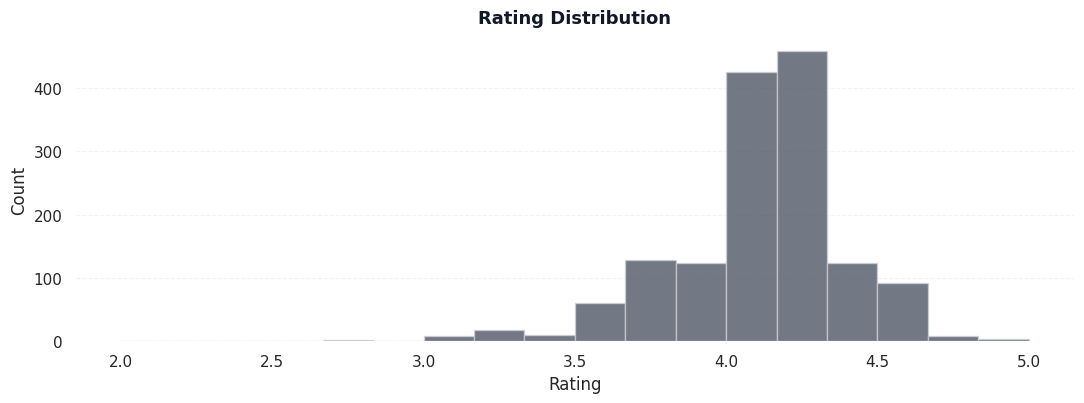

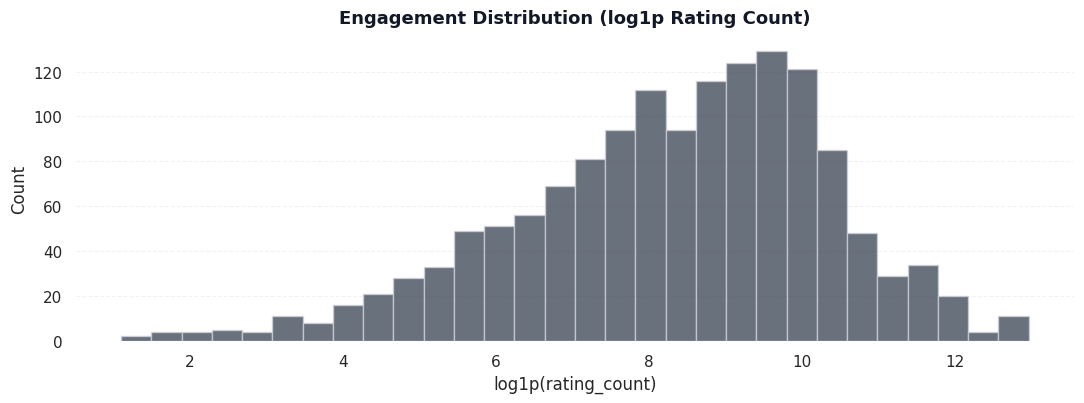

In [7]:
# Rating distribution
fig, ax = plt.subplots(figsize=(11.0, 4.2))
hatch_panel(ax, alpha=0.05)
ax.hist(df["rating"].dropna(), bins=18, edgecolor=THEME["grid"], alpha=0.70, color=THEME["slate"])
ax_title(ax, "Rating Distribution")
ax.set_xlabel("Rating"); ax.set_ylabel("Count")
faint_dashed_ygrid(ax); remove_spines(ax)
plt.tight_layout(); plt.show()

# Rating_count distribution (log scale) — engagement proxy
x = df["rating_count"].dropna()
fig, ax = plt.subplots(figsize=(11.0, 4.2))
hatch_panel(ax, alpha=0.05)
ax.hist(np.log1p(x), bins=30, edgecolor=THEME["grid"], alpha=0.75, color=THEME["slate"])
ax_title(ax, "Engagement Distribution (log1p Rating Count)")
ax.set_xlabel("log1p(rating_count)"); ax.set_ylabel("Count")
faint_dashed_ygrid(ax); remove_spines(ax)
plt.tight_layout(); plt.show()

## 4.2 Discount & Price Landscape (pp + log INR)

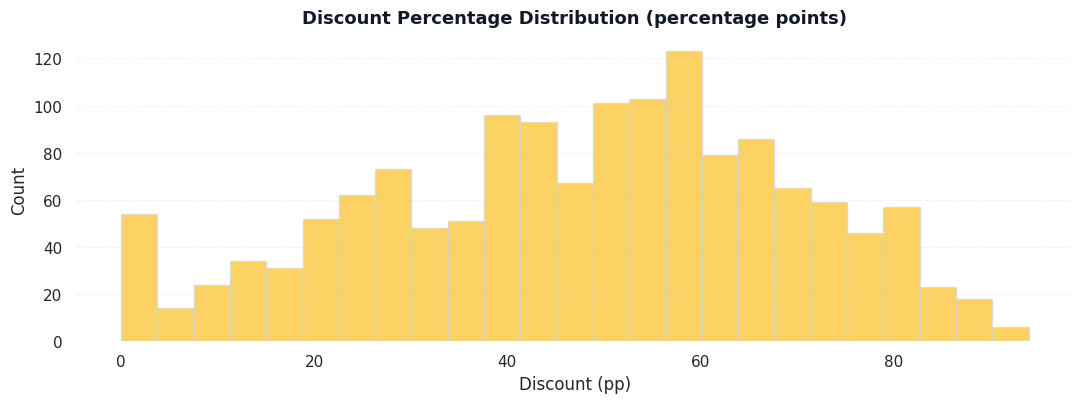

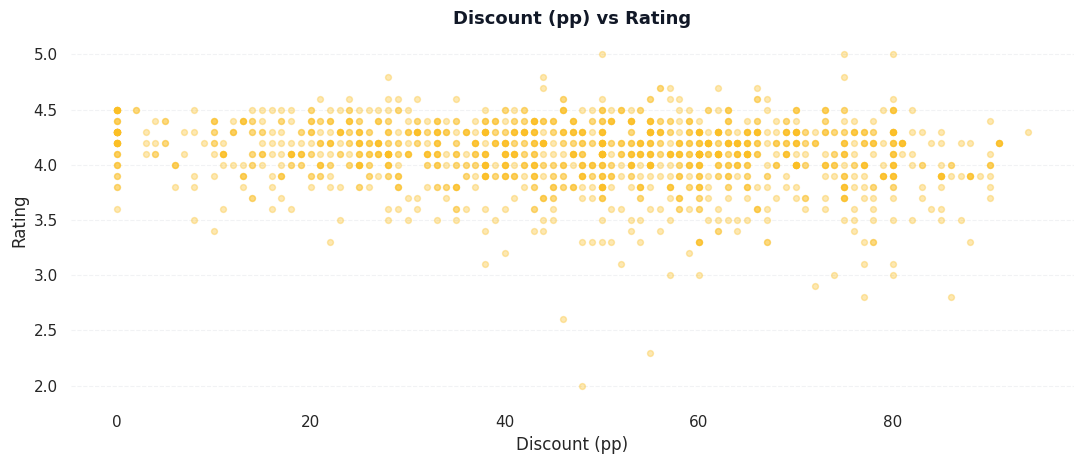

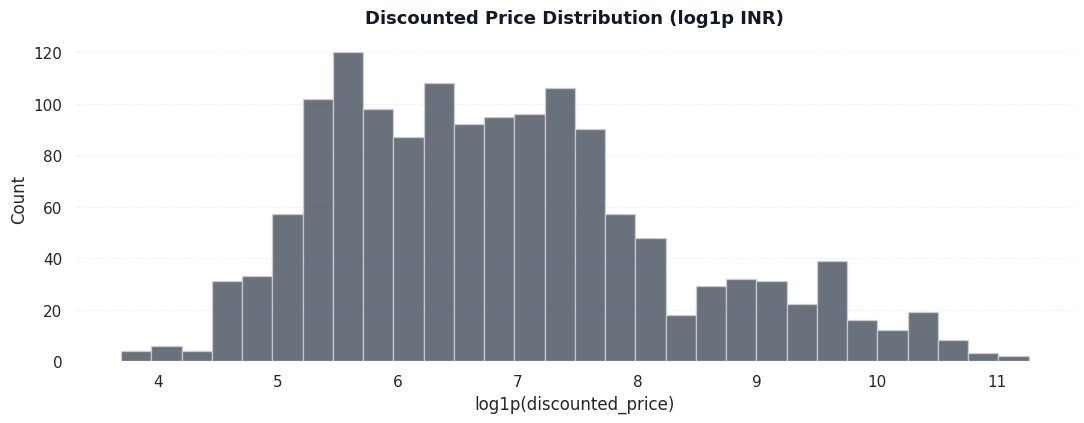

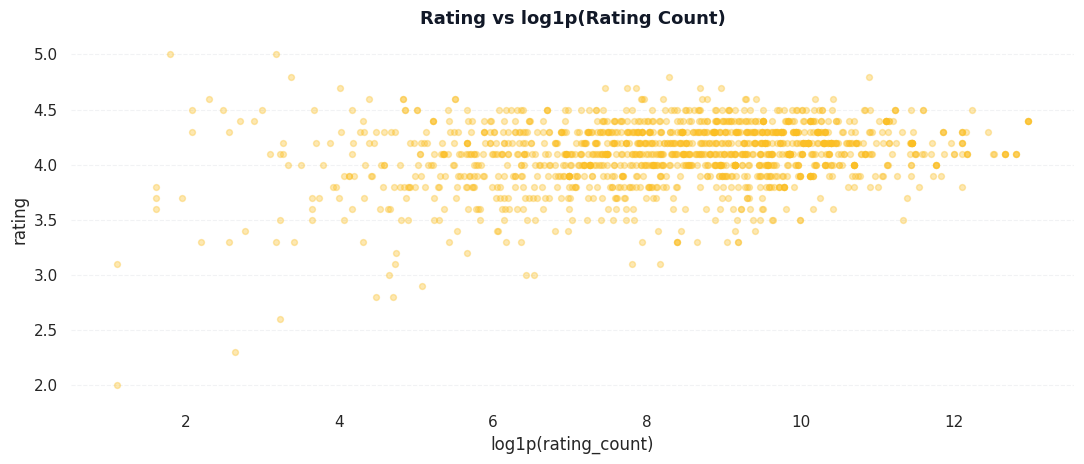

In [8]:
# Discount percentage distribution (pp)
fig, ax = plt.subplots(figsize=(11.0, 4.2))
hatch_panel(ax, alpha=0.05)
x = df["discount_percentage"].dropna()
ax.hist(x, bins=25, edgecolor=THEME["grid"], alpha=0.70, color=THEME["yellow"])
ax_title(ax, "Discount Percentage Distribution (percentage points)")
ax.set_xlabel("Discount (pp)"); ax.set_ylabel("Count")
faint_dashed_ygrid(ax); remove_spines(ax)
plt.tight_layout(); plt.show()

# Discount vs Rating scatter (signal check)
plot_df = df.dropna(subset=["discount_percentage", "rating"]).copy()
fig, ax = plt.subplots(figsize=(11.0, 4.8))
hatch_panel(ax, alpha=0.05)
ax.scatter(plot_df["discount_percentage"], plot_df["rating"], alpha=0.35, s=18, color=THEME["yellow"])
ax_title(ax, "Discount (pp) vs Rating")
ax.set_xlabel("Discount (pp)"); ax.set_ylabel("Rating")
faint_dashed_ygrid(ax); remove_spines(ax)
plt.tight_layout(); plt.show()

# Discounted price distribution (log INR)
fig, ax = plt.subplots(figsize=(11.0, 4.4))
hatch_panel(ax, alpha=0.05)
x = df["discounted_price"].dropna()
ax.hist(np.log1p(x), bins=30, edgecolor=THEME["grid"], alpha=0.75, color=THEME["slate"])
ax_title(ax, "Discounted Price Distribution (log1p INR)")
ax.set_xlabel("log1p(discounted_price)"); ax.set_ylabel("Count")
faint_dashed_ygrid(ax); remove_spines(ax)
plt.tight_layout(); plt.show()

# Rating vs log(votes)
plot_df = df.dropna(subset=["rating", "rating_count"]).copy()
plot_df["log_votes"] = np.log1p(plot_df["rating_count"])
fig, ax = plt.subplots(figsize=(11.0, 4.8))
hatch_panel(ax, alpha=0.05)
ax.scatter(plot_df["log_votes"], plot_df["rating"], s=18, alpha=0.35, color=THEME["yellow"])
ax_title(ax, "Rating vs log1p(Rating Count)")
ax.set_xlabel("log1p(rating_count)"); ax.set_ylabel("rating")
faint_dashed_ygrid(ax); remove_spines(ax)
plt.tight_layout(); plt.show()

## 4.3 Discount Integrity Diagnostics (soft drift, hard mismatch, tail risk)

,mean_pp_diff,p50_pp_diff,p90_pp_diff,p95_pp_diff,p99_pp_diff,max_pp_diff
0,0.2092,0.1841,0.4458,0.4719,0.4895,0.5000


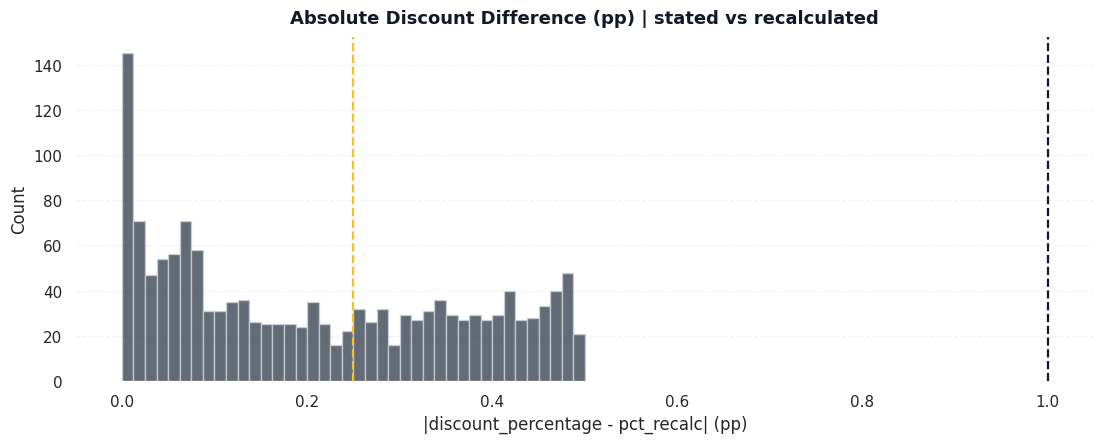

In [9]:
pct_recalc = np.where(
    df["actual_price"].gt(0),
    100.0 * ((df["actual_price"] - df["discounted_price"]) / df["actual_price"]),
    np.nan
)
pct_diff_abs = np.abs(df["discount_percentage"] - pct_recalc)

# 3-tier governance thresholds (pp)
THRESH_SOFT_PP   = 0.25  
THRESH_HARD_PP   = 1.00   
THRESH_DEFECT_PP = 3.00  

soft_flag = (pd.notna(pct_recalc) & df["discount_percentage"].notna() & (pct_diff_abs > THRESH_SOFT_PP)).astype(int)
hard_flag = (pd.notna(pct_recalc) & df["discount_percentage"].notna() & (pct_diff_abs > THRESH_HARD_PP)).astype(int)
defect_flag = (pd.notna(pct_recalc) & df["discount_percentage"].notna() & (pct_diff_abs > THRESH_DEFECT_PP)).astype(int)

# Quantile profile
q_tbl = pd.DataFrame([{
    "mean_pp_diff": float(np.nanmean(pct_diff_abs)),
    "p50_pp_diff":  float(np.nanpercentile(pct_diff_abs, 50)),
    "p90_pp_diff":  float(np.nanpercentile(pct_diff_abs, 90)),
    "p95_pp_diff":  float(np.nanpercentile(pct_diff_abs, 95)),
    "p99_pp_diff":  float(np.nanpercentile(pct_diff_abs, 99)),
    "max_pp_diff":  float(np.nanmax(pct_diff_abs)),
}])

df_tabs([("Discount Diff Quantiles (pp)", q_tbl, 4, 10)],
        panel_title="Discount Consistency — Quantile Profile")

kpi_cards([
    {"title":"Mean |pp diff|", "value":f"{np.nanmean(pct_diff_abs):.3f}", "accent":THEME["muted"]},
    {"title":"P95 |pp diff|",  "value":f"{np.nanpercentile(pct_diff_abs, 95):.3f}", "accent":THEME["slate"]},
    {"title":f"Soft Drift Rate (>{THRESH_SOFT_PP}pp)", "value":f"{soft_flag.mean():.4f}", "accent":THEME["yellow"]},
    {"title":f"Hard Mismatch Rate (>{THRESH_HARD_PP}pp)", "value":f"{hard_flag.mean():.4f}", "accent":THEME["slate"]},
])

# Distribution + threshold lines
fig, ax = plt.subplots(figsize=(11.2, 4.6))
hatch_panel(ax, alpha=0.05)
x = pd.Series(pct_diff_abs).dropna()
ax.hist(x, bins=40, edgecolor=THEME["grid"], alpha=0.78, color=THEME["slate"])
ax.axvline(THRESH_SOFT_PP, linestyle="--", linewidth=1.6, color=THEME["yellow"])
ax.axvline(THRESH_HARD_PP, linestyle="--", linewidth=1.6, color=THEME["text"])
ax_title(ax, "Absolute Discount Difference (pp) | stated vs recalculated")
ax.set_xlabel("|discount_percentage - pct_recalc| (pp)")
ax.set_ylabel("Count")
faint_dashed_ygrid(ax); remove_spines(ax)
plt.tight_layout(); plt.show()

# 5. 🧾 CATEGORY EXECUTIVE SCORECARDS

## 5.1 L1–L3 Coverage & Top Categories

In [10]:
if "cat_l1" in df.columns:
    cov = pd.DataFrame({
        "Level": ["L1", "L2", "L3"],
        "NonNull_Rows": [
            int(df["cat_l1"].notna().sum()) if "cat_l1" in df.columns else 0,
            int(df["cat_l2"].notna().sum()) if "cat_l2" in df.columns else 0,
            int(df["cat_l3"].notna().sum()) if "cat_l3" in df.columns else 0,
        ],
        "Unique": [
            int(df["cat_l1"].nunique(dropna=True)) if "cat_l1" in df.columns else 0,
            int(df["cat_l2"].nunique(dropna=True)) if "cat_l2" in df.columns else 0,
            int(df["cat_l3"].nunique(dropna=True)) if "cat_l3" in df.columns else 0,
        ]
    })
    df_tabs([("Category Coverage", cov, 0, 10)], panel_title="Taxonomy Coverage (L1–L3)")

    top_l1 = df["cat_l1"].value_counts(dropna=True).head(15).reset_index()
    top_l1.columns = ["cat_l1", "rows"]
    df_tabs([("Top L1 Categories", top_l1, 0, 20)], panel_title="Top Categories (L1)")

,Level,NonNull_Rows,Unique
0,L1,1465,9
1,L2,1465,29
2,L3,1457,71


,cat_l1,rows
0,Electronics,526
1,Computers&Accessories,453
2,Home&Kitchen,448
3,OfficeProducts,31
4,MusicalInstruments,2
5,HomeImprovement,2
6,Toys&Games,1
7,Car&Motorbike,1
8,Health&PersonalCare,1


## 5.2 Category KPIs (rating, discount, price medians)

In [11]:
if "cat_l1" in df.columns:
    cat_kpis = (
        df.groupby("cat_l1", dropna=True)
          .agg(
              rows=("product_id", "size") if "product_id" in df.columns else ("rating", "size"),
              unique_products=("product_id", "nunique") if "product_id" in df.columns else ("rating", "size"),
              avg_rating=("rating", "mean"),
              med_discount_pp=("discount_percentage", "median"),
              med_discounted_price_inr=("discounted_price", "median"),
              multi_user_rate=("multi_user_flag", "mean"),
              defect_rate=("discount_inconsistency_flag", "mean"),
          )
          .reset_index()
          .sort_values("unique_products", ascending=False)
          .head(15)
    )
    df_tabs([("L1 KPI Scorecard (Top 15)", cat_kpis, 4, 50)], panel_title="Category Executive Scorecard (L1)")

,cat_l1,rows,unique_products,avg_rating,med_discount_pp,med_discounted_price_inr,multi_user_rate,defect_rate
2,Electronics,526,490,4.0817,54.0000,1399.0000,0.9981,0.0000
4,Home&Kitchen,448,448,4.0407,41.5000,1199.0000,0.9978,0.0000
1,Computers&Accessories,453,375,4.1550,58.0000,349.0000,0.9956,0.0000
7,OfficeProducts,31,31,4.3097,5.0000,178.0000,1.0000,0.0000
6,MusicalInstruments,2,2,3.9000,46.0000,638.0000,1.0000,0.0000
5,HomeImprovement,2,2,4.2500,57.5000,337.0000,1.0000,0.0000
0,Car&Motorbike,1,1,3.8000,42.0000,2339.0000,1.0000,0.0000
3,Health&PersonalCare,1,1,4.0000,53.0000,899.0000,1.0000,0.0000
8,Toys&Games,1,1,4.3000,0.0000,150.0000,1.0000,0.0000


## 5.3 Governance by Category (soft drift rate + P95 pp diff)

,cat_l1,rows,soft_rate,hard_rate,defect_rate,mean_pp_diff,p95_pp_diff
1,Computers&Accessories,453,0.4570,0.0000,0.0000,0.2308,0.4757
4,Home&Kitchen,448,0.4442,0.0000,0.0000,0.2209,0.4689
2,Electronics,526,0.3517,0.0000,0.0000,0.1862,0.4690
7,OfficeProducts,31,0.1613,0.0000,0.0000,0.0989,0.4018


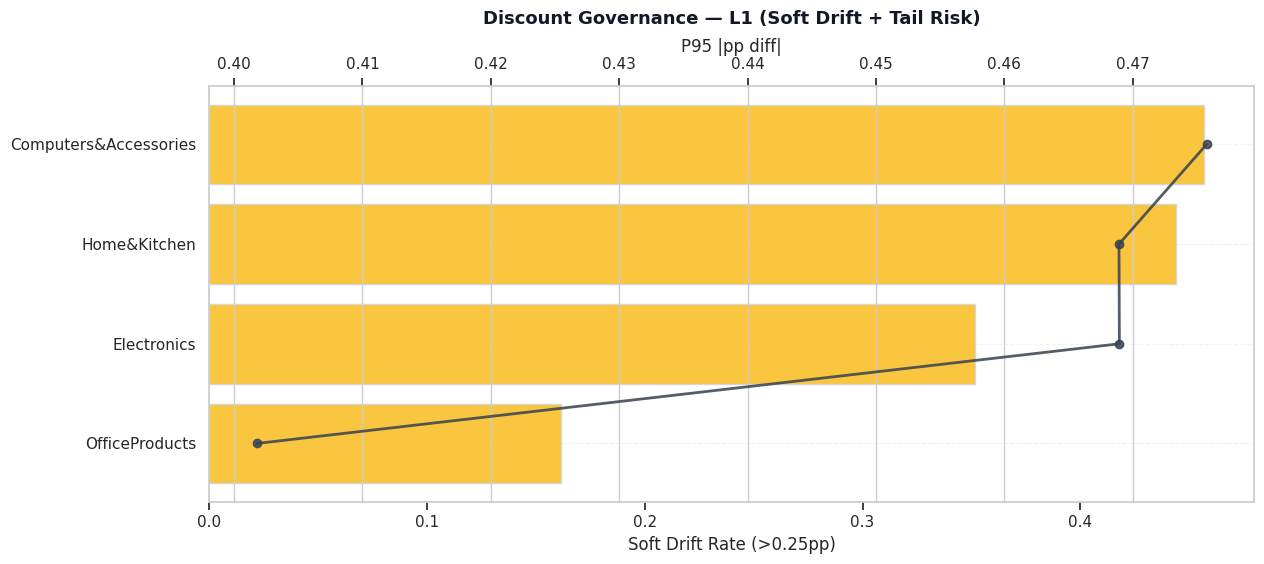

In [12]:
if "cat_l1" in df.columns:
    MIN_ROWS_PER_CAT = 30

    inc_tbl = (
        df.assign(
            pct_diff_abs=pct_diff_abs,
            soft_flag=soft_flag,
            hard_flag=hard_flag,
            defect_flag=defect_flag
        )
        .groupby("cat_l1", dropna=True)
        .agg(
            rows=("product_id", "size") if "product_id" in df.columns else ("rating", "size"),
            soft_rate=("soft_flag", "mean"),
            hard_rate=("hard_flag", "mean"),
            defect_rate=("defect_flag", "mean"),
            mean_pp_diff=("pct_diff_abs", "mean"),
            p95_pp_diff=("pct_diff_abs", lambda s: np.nanpercentile(s, 95)),
        )
        .reset_index()
    )

    inc_tbl = inc_tbl[inc_tbl["rows"] >= MIN_ROWS_PER_CAT].copy()
    inc_tbl = inc_tbl.sort_values(["soft_rate", "p95_pp_diff", "rows"], ascending=False).head(12)

    df_tabs([("L1 Governance (Top 12)", inc_tbl, 4, 50)], panel_title="Discount Governance — L1 (Soft Drift + Tail Risk)")

    # Executive chart: Soft drift (bars) + P95 tail risk (line)
    fig, ax = plt.subplots(figsize=(12.8, 5.8))
    hatch_panel(ax, alpha=0.05)

    plot_tbl = inc_tbl.sort_values("soft_rate", ascending=True)
    y = np.arange(len(plot_tbl))

    ax.barh(y, plot_tbl["soft_rate"], edgecolor=THEME["grid"], alpha=0.88, color=THEME["yellow"])
    ax.set_yticks(y)
    ax.set_yticklabels(plot_tbl["cat_l1"])
    ax.set_xlabel(f"Soft Drift Rate (>{THRESH_SOFT_PP}pp)")
    ax.set_ylabel("")

    ax2 = ax.twiny()
    ax2.plot(plot_tbl["p95_pp_diff"], y, marker="o", linewidth=2.0, alpha=0.85, color=THEME["slate"])
    ax2.set_xlabel("P95 |pp diff|")

    ax_title(ax, "Discount Governance — L1 (Soft Drift + Tail Risk)")
    faint_dashed_ygrid(ax); remove_spines(ax)
    plt.tight_layout(); plt.show()

### Key Takeaways — Discount Governance (L1 Categories)

- **No hard defects detected:** All categories show a **hard_rate = 0.000**, confirming there are no material discount mismatches above the defect threshold.  
- **Soft drift is category-dependent:**  
  - **Computers & Accessories** and **Home & Kitchen** exhibit the **highest soft drift rates (~44–46%)**, indicating frequent small rounding or sync differences.  
  - **Electronics** shows a **moderate drift level (~35%)**.  
  - **Office Products** is the **cleanest segment (~16%)** with the lowest operational noise.  
- **Tail risk remains controlled:** **P95 pp differences stay below ~0.48pp** across all categories, suggesting that even in worst-case scenarios, discount deviations remain small and non-critical.  

**Interpretation:** Discount signals are operationally stable across categories, with variation driven by small, systematic drift rather than true integrity defects.

# 6. 🤖 MODELLING — “SATISFACTION RISK” CLASSIFICATION

In [13]:
RATING_THRESHOLD = 4.0
MIN_VOTES = 50

df_model = df.copy()

df_model["rating"] = pd.to_numeric(df_model["rating"], errors="coerce")

if "rating_count_int" in df_model.columns:
    votes = pd.to_numeric(df_model["rating_count_int"], errors="coerce")
else:
    votes = pd.to_numeric(df_model.get("rating_count", np.nan), errors="coerce")

df_model["rating_count"] = votes  

df_model = df_model.dropna(subset=["rating"]).copy()
df_model = df_model[df_model["rating_count"].fillna(0) >= MIN_VOTES].copy()

df_model["at_risk"] = (df_model["rating"] < RATING_THRESHOLD).astype("int64")

kpi_cards([
    {"title": f"Model Rows (votes>={MIN_VOTES:,})", "value": f"{len(df_model):,}", "accent": THEME["slate"]},
    {"title": "At-Risk Rate", "value": f"{df_model['at_risk'].mean()*100:.1f}%", "accent": THEME["yellow"]},
    {"title": "Avg Rating", "value": f"{df_model['rating'].mean():.3f}", "accent": THEME["muted"]},
])

if "cat_l1" in df_model.columns:
    risk_l1_snapshot = (
        df_model.groupby("cat_l1", dropna=False)
                .agg(
                    rows=("product_id", "size") if "product_id" in df_model.columns else ("rating", "size"),
                    at_risk_rate=("at_risk", "mean"),
                    avg_rating=("rating", "mean"),
                )
                .reset_index()
    )

    risk_l1_snapshot["rows"] = risk_l1_snapshot["rows"].astype("int64").map(lambda x: f"{x:,}")
    risk_l1_snapshot["at_risk_rate"] = risk_l1_snapshot["at_risk_rate"].map(lambda v: f"{v*100:.1f}%")
    risk_l1_snapshot["avg_rating"] = risk_l1_snapshot["avg_rating"].map(lambda v: "—" if pd.isna(v) else f"{v:.2f}")

    risk_l1_snapshot = risk_l1_snapshot.sort_values("rows", ascending=False).head(12)

    df_tabs(
        [("At-Risk Snapshot (Top L1)", risk_l1_snapshot, 4, 30)],
        panel_title=f"Operational Baseline — L1 View (votes>={MIN_VOTES:,})"
    )
else:
    df_tabs(
        [("At-Risk Snapshot (Top L1)", pd.DataFrame({"note": ["cat_l1 not available."]}), 0, 5)],
        panel_title=f"Operational Baseline — L1 View (votes>={MIN_VOTES:,})"
    )

,cat_l1,rows,at_risk_rate,avg_rating
2,Electronics,514,25.3%,4.08
1,Computers&Accessories,447,16.3%,4.15
4,Home&Kitchen,423,30.5%,4.06
7,OfficeProducts,31,0.0%,4.31
5,HomeImprovement,2,0.0%,4.25
6,MusicalInstruments,2,50.0%,3.90
0,Car&Motorbike,1,100.0%,3.80
3,Health&PersonalCare,1,0.0%,4.00
8,Toys&Games,1,0.0%,4.30


### Key Takeaways — Satisfaction Risk Baseline (L1 View, votes ≥ 50)

- **Model scope:** The risk model operates on **1,422 products** with sufficient engagement, ensuring results are not driven by low-sample noise.  
- **Overall risk level:** **23.5% of products** fall into the **At-Risk** segment (rating < 4.0), with an **average rating of 4.10** across the governed dataset.  
- **Highest risk exposure:**  
  - **Home & Kitchen** shows the **largest at-risk share (~30.5%)**, making it the primary category for quality and content review.  
  - **Electronics** follows with a **moderate risk level (~25.3%)** at high volume, indicating operational impact at scale.  
- **Lower risk segments:**  
  - **Computers & Accessories** performs relatively well with a **lower at-risk rate (~16.3%)**.  
  - **Office Products** shows **no at-risk cases** within the gated sample, signaling stable satisfaction.  

**Interpretation:** Risk is concentrated in high-volume consumer categories, suggesting prioritization for QA, pricing validation, and expectation management should focus on **Home & Kitchen** and **Electronics**.

## 6.2 Feature Policy (structured + taxonomy + text tracks)

In [14]:
def safe_text_col(dfx, col):
    return dfx[col].fillna("").astype(str) if col in dfx.columns else ""

df_model["text_listing"] = (
    safe_text_col(df_model, "product_name") + " " +
    safe_text_col(df_model, "about_product") + " " +
    safe_text_col(df_model, "category")
).str.strip()

df_model["text_review"] = (
    safe_text_col(df_model, "review_title_clean") + " " +
    safe_text_col(df_model, "review_content_clean")
).str.strip()

df_model["text_all"] = (df_model["text_listing"] + " " + df_model["text_review"]).str.strip()

# Minimal structured enrichments (model-only)
df_model["discount_amount_inr"] = df_model["actual_price"] - df_model["discounted_price"]
df_model["price_ratio"] = np.where(df_model["actual_price"].gt(0), df_model["discounted_price"] / df_model["actual_price"], np.nan)
df_model["log_rating_count"] = np.log1p(df_model["rating_count"].fillna(0))
df_model["review_word_len"] = df_model["review_content_clean"].fillna("").astype(str).str.split().apply(len)
df_model["exclamation_cnt"] = df_model["review_content_clean"].fillna("").astype(str).str.count("!")

NUM_COLS = [
    "actual_price","discounted_price","discount_percentage","discount_amount_inr","price_ratio",
    "rating_count","log_rating_count","review_char_len","review_word_len","exclamation_cnt",
    "n_users_inferred","discount_inconsistency_flag",
]
NUM_COLS = [c for c in NUM_COLS if c in df_model.columns]

CAT_COLS = [c for c in ["cat_l1","cat_l2","cat_l3"] if c in df_model.columns]

feature_policy = pd.DataFrame({
    "FeatureSet": (["NUM_COLS"] * len(NUM_COLS)) + (["CAT_COLS"] * len(CAT_COLS)) + (["TEXT"] * 2),
    "Feature": NUM_COLS + CAT_COLS + ["text_listing", "text_all"],
    "Rationale": (["Typed pricing/discount + engagement + governance + minimal VoC signals"] * len(NUM_COLS)
                 + ["Category taxonomy (L1–L3) for segmentation signal"] * len(CAT_COLS)
                 + ["Pre-purchase listing signal", "Post-purchase VoC + listing combined signal"])
})

df_tabs([("Feature Policy", feature_policy, 2, 200)], panel_title="Feature Policy (Selected / Engineered)")

,FeatureSet,Feature,Rationale
0,NUM_COLS,actual_price,Typed pricing/discount + engagement + governance + minimal VoC signals
1,NUM_COLS,discounted_price,Typed pricing/discount + engagement + governance + minimal VoC signals
2,NUM_COLS,discount_percentage,Typed pricing/discount + engagement + governance + minimal VoC signals
3,NUM_COLS,discount_amount_inr,Typed pricing/discount + engagement + governance + minimal VoC signals
4,NUM_COLS,price_ratio,Typed pricing/discount + engagement + governance + minimal VoC signals
5,NUM_COLS,rating_count,Typed pricing/discount + engagement + governance + minimal VoC signals
6,NUM_COLS,log_rating_count,Typed pricing/discount + engagement + governance + minimal VoC signals
7,NUM_COLS,review_char_len,Typed pricing/discount + engagement + governance + minimal VoC signals
8,NUM_COLS,review_word_len,Typed pricing/discount + engagement + governance + minimal VoC signals
9,NUM_COLS,exclamation_cnt,Typed pricing/discount + engagement + governance + minimal VoC signals


## 6.3 Benchmarking (CV PR-AUC/ROC-AUC) + Champion Selection

,Model,CV_ROC_AUC_Mean,CV_ROC_AUC_Std,CV_PR_AUC_Mean,CV_PR_AUC_Std
0,LinearSVC,0.8596,0.0310,0.7053,0.0343
1,SGD_logloss,0.8384,0.0329,0.6665,0.0397
2,LogReg_saga,0.8170,0.0322,0.6121,0.0286
,Model,CV_ROC_AUC_Mean,CV_ROC_AUC_Std,CV_PR_AUC_Mean,CV_PR_AUC_Std
0,LinearSVC,0.8635,0.0262,0.7126,0.0225
1,SGD_logloss,0.8250,0.0369,0.6171,0.1206
2,LogReg_saga,0.8169,0.0335,0.6147,0.0302
,Model,CV_ROC_AUC_Mean,CV_ROC_AUC_Std,CV_PR_AUC_Mean,CV_PR_AUC_Std
0,RandomForest,0.8374,0.0166,0.6553,0.0171
1,LightGBM,0.7863,0.0081,0.5756,0.0237


,Model,CV_ROC_AUC_Mean,CV_ROC_AUC_Std,CV_PR_AUC_Mean,CV_PR_AUC_Std
0,Uplift_LinearSVC(C=2.0),0.8669,0.0207,0.7146,0.0203
1,Uplift_LinearSVC(C=1.0),0.8687,0.0201,0.7145,0.0207
2,Uplift_LinearSVC(C=4.0),0.8659,0.0209,0.7125,0.0198
3,Uplift_LinearSVC(C=0.5),0.8683,0.0220,0.7122,0.0256
4,Uplift_LinearSVC(C=0.25),0.8627,0.0245,0.7017,0.0271


Uplift champion: Uplift_LinearSVC(C=2.0)



————————————————————————————————————————————————————————————————————————————————————————————
CLASSIFICATION REPORT (Text Listing-only (Best=LinearSVC))
————————————————————————————————————————————————————————————————————————————————————————————
              precision    recall  f1-score   support

     Healthy       0.89      0.90      0.89       218
     At-Risk       0.66      0.64      0.65        67

    accuracy                           0.84       285
   macro avg       0.78      0.77      0.77       285
weighted avg       0.84      0.84      0.84       285



,Pred_Healthy,Pred_AtRisk
True_Healthy,196,22
True_AtRisk,24,43


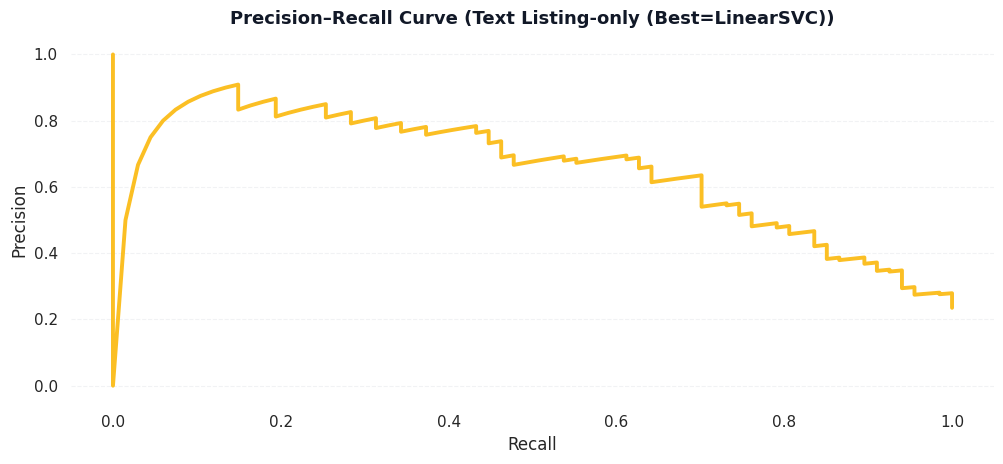

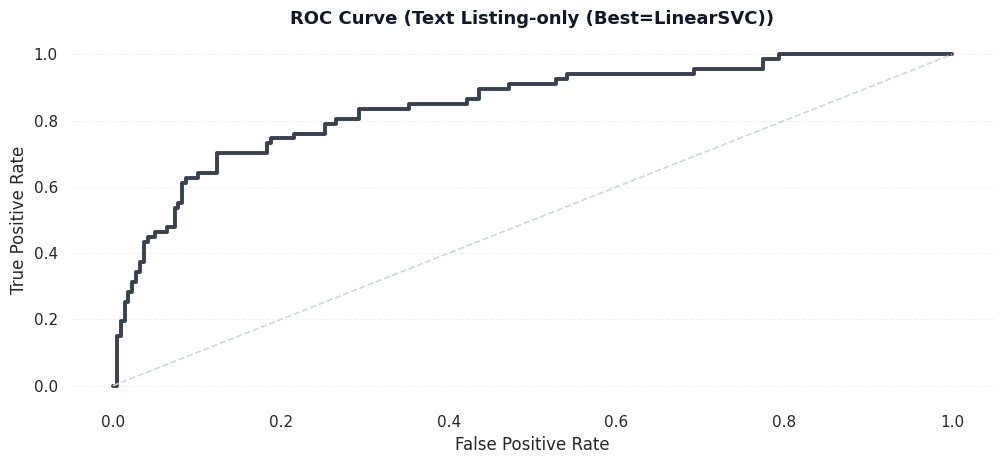


————————————————————————————————————————————————————————————————————————————————————————————
CLASSIFICATION REPORT (Text Listing+Review (Best=LinearSVC))
————————————————————————————————————————————————————————————————————————————————————————————
              precision    recall  f1-score   support

     Healthy       0.88      0.92      0.90       218
     At-Risk       0.69      0.60      0.64        67

    accuracy                           0.84       285
   macro avg       0.79      0.76      0.77       285
weighted avg       0.84      0.84      0.84       285



,Pred_Healthy,Pred_AtRisk
True_Healthy,200,18
True_AtRisk,27,40


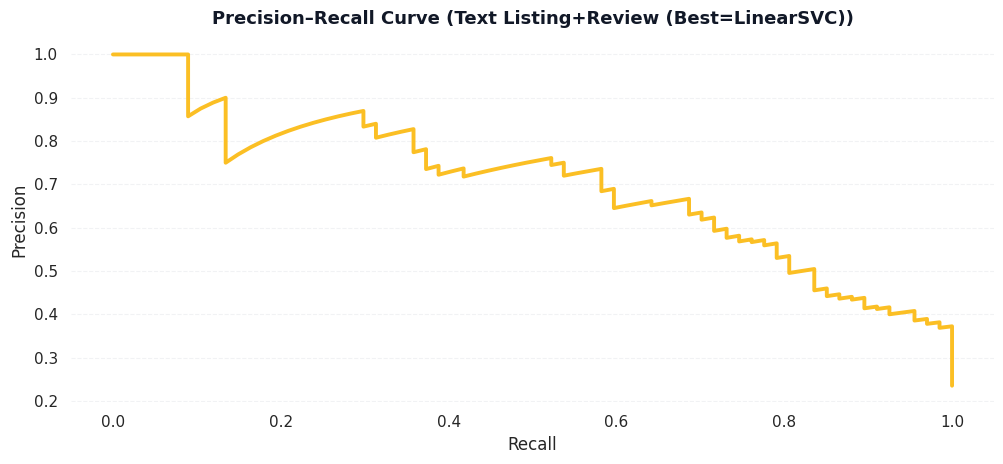

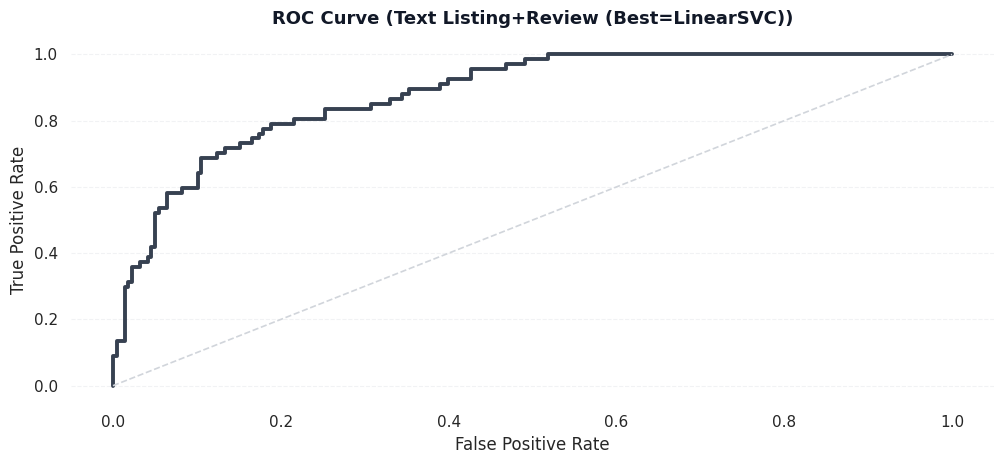


————————————————————————————————————————————————————————————————————————————————————————————
CLASSIFICATION REPORT (Structured-only (Best=RandomForest))
————————————————————————————————————————————————————————————————————————————————————————————
              precision    recall  f1-score   support

     Healthy       0.81      0.94      0.87       218
     At-Risk       0.61      0.28      0.39        67

    accuracy                           0.79       285
   macro avg       0.71      0.61      0.63       285
weighted avg       0.76      0.79      0.76       285



,Pred_Healthy,Pred_AtRisk
True_Healthy,206,12
True_AtRisk,48,19


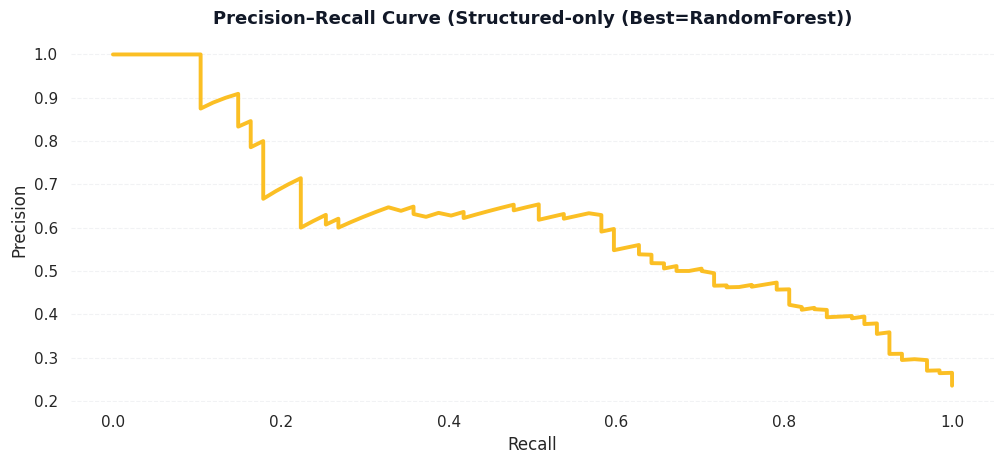

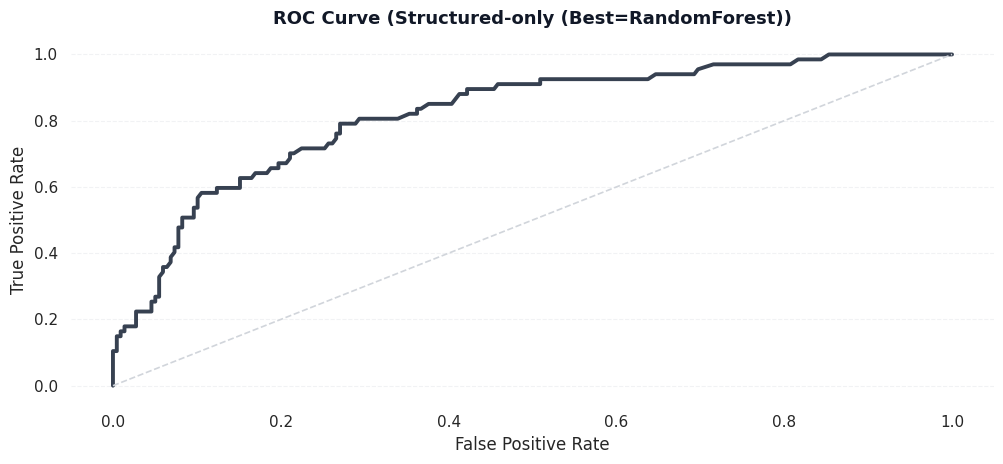


————————————————————————————————————————————————————————————————————————————————————————————
CLASSIFICATION REPORT (Uplift TextAllClean (Best=Uplift_LinearSVC(C=2.0)))
————————————————————————————————————————————————————————————————————————————————————————————
              precision    recall  f1-score   support

     Healthy       0.89      0.94      0.91       218
     At-Risk       0.75      0.61      0.67        67

    accuracy                           0.86       285
   macro avg       0.82      0.77      0.79       285
weighted avg       0.85      0.86      0.85       285



,Pred_Healthy,Pred_AtRisk
True_Healthy,204,14
True_AtRisk,26,41


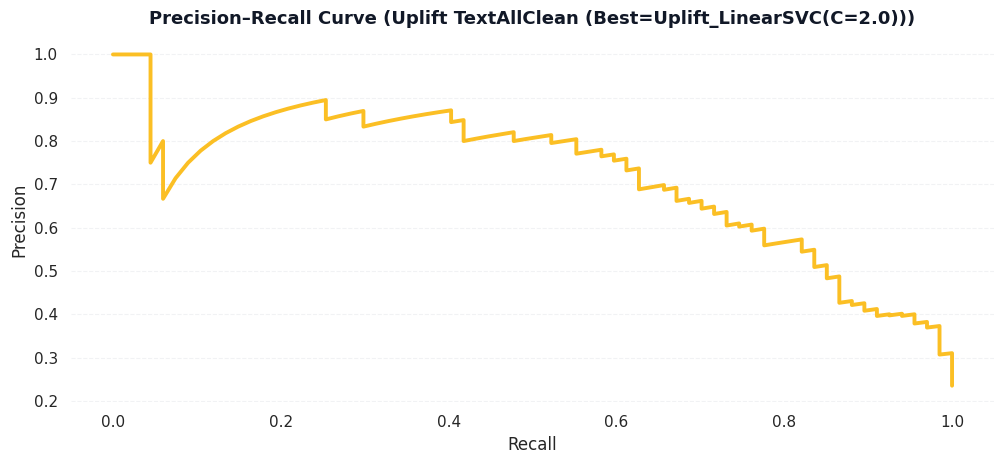

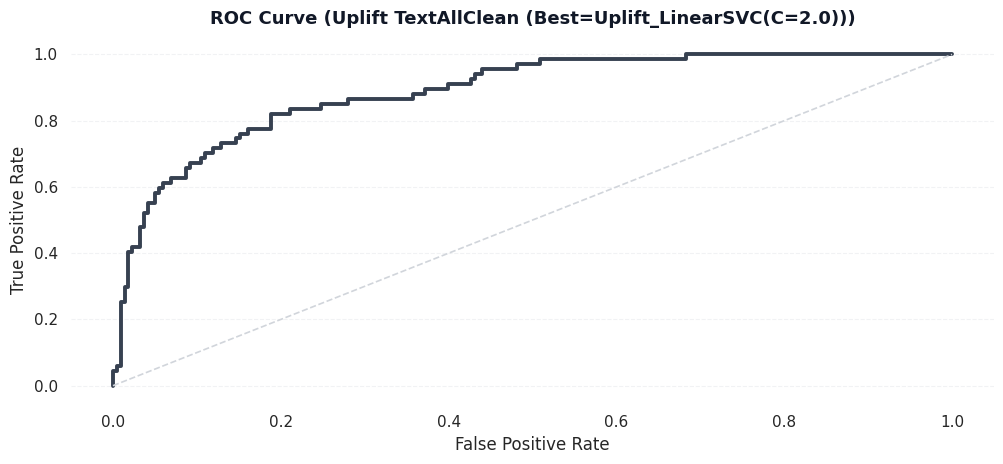

,Track,ROC_AUC,PR_AUC,Accuracy,F1,Recall,Precision
0,Uplift TextAllClean,0.8879,0.7231,0.8596,0.6721,0.6119,0.7455
1,Text Listing+Review,0.8805,0.7032,0.8421,0.6400,0.5970,0.6897
2,Text Listing-only,0.8452,0.6560,0.8386,0.6515,0.6418,0.6615
3,Structured-only,0.8198,0.6095,0.7895,0.3878,0.2836,0.6129


Selected Champion Track: Uplift TextAllClean


In [15]:
SEED = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = {"roc_auc": "roc_auc", "pr_auc": "average_precision"}  # PR-AUC is primary for risk detection

def build_preprocessor_basic(text_col=None, tfidf_max=20000, use_bigrams=True):
    num_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
    transformers = [
        ("num", num_pipe, NUM_COLS),
        ("cat", cat_pipe, CAT_COLS),
    ]
    if text_col is not None:
        text_pipe = TfidfVectorizer(
            max_features=tfidf_max,
            ngram_range=(1,2) if use_bigrams else (1,1),
            min_df=2,
            sublinear_tf=True,
            stop_words="english",
            dtype=np.float32
        )
        transformers.append(("txt", text_pipe, text_col))
    return ColumnTransformer(transformers=transformers, remainder="drop")

def benchmark_pipelines(pipelines, X, y):
    rows, registry = [], {}
    for name, pipe in pipelines:
        out = cross_validate(pipe, X, y, cv=cv, scoring=SCORING, n_jobs=1)
        rows.append({
            "Model": name,
            "CV_ROC_AUC_Mean": float(np.mean(out["test_roc_auc"])),
            "CV_ROC_AUC_Std":  float(np.std(out["test_roc_auc"])),
            "CV_PR_AUC_Mean":  float(np.mean(out["test_pr_auc"])),
            "CV_PR_AUC_Std":   float(np.std(out["test_pr_auc"])),
        })
        registry[name] = pipe
    score_df = (pd.DataFrame(rows)
                  .sort_values(["CV_PR_AUC_Mean","CV_ROC_AUC_Mean"], ascending=False)
                  .reset_index(drop=True))
    return score_df, registry

target = "at_risk"
X = df_model[NUM_COLS + CAT_COLS + ["text_listing", "text_all"]].copy()
y = df_model[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

# Track A: Text listing-only
pre_listing = build_preprocessor_basic(text_col="text_listing", tfidf_max=20000, use_bigrams=True)
pipelines_listing = [
    ("LogReg_saga", Pipeline([("prep", pre_listing),
                             ("model", LogisticRegression(max_iter=5000, solver="saga",
                                                          class_weight="balanced", n_jobs=-1, random_state=SEED))])),
    ("LinearSVC", Pipeline([("prep", pre_listing),
                           ("model", LinearSVC(class_weight="balanced", random_state=SEED))])),
    ("SGD_logloss", Pipeline([("prep", pre_listing),
                             ("model", SGDClassifier(loss="log_loss", alpha=1e-4, max_iter=2500,
                                                     class_weight="balanced", random_state=SEED))])),
]
score_listing, reg_listing = benchmark_pipelines(pipelines_listing, X_train, y_train)

# Track B: Text listing+review
pre_all = build_preprocessor_basic(text_col="text_all", tfidf_max=20000, use_bigrams=True)
pipelines_all = [
    ("LogReg_saga", Pipeline([("prep", pre_all),
                             ("model", LogisticRegression(max_iter=5000, solver="saga",
                                                          class_weight="balanced", n_jobs=-1, random_state=SEED))])),
    ("LinearSVC", Pipeline([("prep", pre_all),
                           ("model", LinearSVC(class_weight="balanced", random_state=SEED))])),
    ("SGD_logloss", Pipeline([("prep", pre_all),
                             ("model", SGDClassifier(loss="log_loss", alpha=1e-4, max_iter=2500,
                                                     class_weight="balanced", random_state=SEED))])),
]
score_all, reg_all = benchmark_pipelines(pipelines_all, X_train, y_train)

# Track C: Structured-only
pre_struct = build_preprocessor_basic(text_col=None)
pipelines_struct = [
    ("RandomForest", Pipeline([("prep", pre_struct),
                              ("model", RandomForestClassifier(n_estimators=600, n_jobs=-1, random_state=SEED,
                                                               class_weight="balanced_subsample"))])),
    ("GradBoost", Pipeline([("prep", pre_struct),
                           ("model", GradientBoostingClassifier(random_state=SEED))])),
]
if XGB_AVAILABLE:
    pipelines_struct.append(("XGBoost", Pipeline([("prep", pre_struct),
        ("model", XGBClassifier(random_state=SEED, eval_metric="logloss",
                               n_estimators=600, learning_rate=0.05, max_depth=4,
                               subsample=0.9, colsample_bytree=0.9, n_jobs=-1))])))
if LGBM_AVAILABLE:
    pipelines_struct.append(("LightGBM", Pipeline([("prep", pre_struct),
        ("model", LGBMClassifier(random_state=SEED, verbose=-1, n_jobs=-1, class_weight="balanced",
                                 n_estimators=700, learning_rate=0.03, num_leaves=63,
                                 subsample=0.9, colsample_bytree=0.9))])))

score_struct, reg_struct = benchmark_pipelines(pipelines_struct, X_train, y_train)

df_tabs([
    ("Text — Listing-only", score_listing, 4, 20),
    ("Text — Listing+Review", score_all, 4, 20),
    ("Structured — No Text", score_struct, 4, 20),
], panel_title="Benchmark Scorecards (5-Fold CV) — PR-AUC First")

# Uplift track: richer text cleaning + word+char TF-IDF, fast C grid
def clean_text_basic(s):
    s = str(s).lower()
    s = re.sub(r"http\S+|www\.\S+", " URL ", s)
    s = s.replace("₹", " inr ").replace("%", " percent ")
    s = re.sub(r"[^a-z0-9\s]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df_model["text_all_clean"] = df_model["text_all"].map(clean_text_basic)

X_uplift = df_model[NUM_COLS + CAT_COLS + ["text_all_clean"]].copy()
y_uplift = df_model[target].astype(int)

XU_train, XU_test, yU_train, yU_test = train_test_split(
    X_uplift, y_uplift, test_size=0.2, stratify=y_uplift, random_state=SEED
)

def build_preprocessor_rich(text_col, tfidf_word_max=25000, tfidf_char_max=20000):
    num_pipe = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
    cat_pipe = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),
                              ("onehot", OneHotEncoder(handle_unknown="ignore"))])

    tf_word = TfidfVectorizer(max_features=tfidf_word_max, ngram_range=(1,2), min_df=2,
                              sublinear_tf=True, stop_words="english", dtype=np.float32)
    tf_char = TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5), max_features=tfidf_char_max,
                              min_df=3, sublinear_tf=True, dtype=np.float32)

    return ColumnTransformer([
        ("num", num_pipe, NUM_COLS),
        ("cat", cat_pipe, CAT_COLS),
        ("txt_word", tf_word, text_col),
        ("txt_char", tf_char, text_col),
    ], remainder="drop")

def cv_score(pipe, X, y):
    out = cross_validate(pipe, X, y, cv=cv, scoring=SCORING, n_jobs=1)
    return {
        "CV_ROC_AUC_Mean": float(np.mean(out["test_roc_auc"])),
        "CV_ROC_AUC_Std":  float(np.std(out["test_roc_auc"])),
        "CV_PR_AUC_Mean":  float(np.mean(out["test_pr_auc"])),
        "CV_PR_AUC_Std":   float(np.std(out["test_pr_auc"])),
    }

def fast_c_grid_linearsvc(text_col, X, y, C_grid=(0.25, 0.5, 1.0, 2.0, 4.0)):
    rows, reg = [], {}
    pre = build_preprocessor_rich(text_col=text_col)
    for C in C_grid:
        model = LinearSVC(C=C, class_weight="balanced", random_state=SEED)
        pipe = Pipeline([("prep", pre), ("model", model)])
        s = cv_score(pipe, X, y)
        name = f"Uplift_LinearSVC(C={C})"
        rows.append({"Model": name, **s})
        reg[name] = pipe
    df_score = (pd.DataFrame(rows)
                  .sort_values(["CV_PR_AUC_Mean","CV_ROC_AUC_Mean"], ascending=False)
                  .reset_index(drop=True))
    return df_score, reg

score_uplift_svc, reg_uplift_svc = fast_c_grid_linearsvc("text_all_clean", XU_train, yU_train)

df_tabs([("Uplift Grid — LinearSVC", score_uplift_svc, 4, 30)],
        panel_title="Uplift Track — Word+Char TF-IDF (Fast Grid)")

uplift_best_name = score_uplift_svc.iloc[0]["Model"]
uplift_best_pipe = reg_uplift_svc[uplift_best_name]
print("Uplift champion:", uplift_best_name)

# Final evaluation utility (test report)
def fit_evaluate(pipe, X_train, y_train, X_test, y_test, label="Candidate"):
    pipe.fit(X_train, y_train)

    proba = None
    if hasattr(pipe.named_steps["model"], "predict_proba"):
        proba = pipe.predict_proba(X_test)[:, 1]
        pred = (proba >= 0.5).astype(int)
    else:
        pred = pipe.predict(X_test)
        if hasattr(pipe.named_steps["model"], "decision_function"):
            raw = np.asarray(pipe.decision_function(X_test)).ravel()
            proba = (raw - raw.min()) / (raw.max() - raw.min() + 1e-12)

    metrics = {
        "ROC_AUC": float(roc_auc_score(y_test, proba)) if proba is not None else np.nan,
        "PR_AUC":  float(average_precision_score(y_test, proba)) if proba is not None else np.nan,
        "Accuracy": float(accuracy_score(y_test, pred)),
        "F1": float(f1_score(y_test, pred)),
        "Recall": float(recall_score(y_test, pred)),
        "Precision": float(precision_score(y_test, pred)),
    }

    kpi_cards([
        {"title":f"{label}", "value":pipe.named_steps["model"].__class__.__name__, "accent":THEME["slate"]},
        {"title":"Test PR-AUC", "value":f"{metrics['PR_AUC']:.3f}", "accent":THEME["yellow"]},
        {"title":"Test ROC-AUC", "value":f"{metrics['ROC_AUC']:.3f}", "accent":THEME["muted"]},
        {"title":"Test Recall", "value":f"{metrics['Recall']:.3f}", "accent":THEME["yellow_soft"]},
    ])

    print("\n" + "—"*92)
    print(f"CLASSIFICATION REPORT ({label})")
    print("—"*92)
    print(classification_report(y_test, pred, target_names=["Healthy","At-Risk"], zero_division=0))

    cm = confusion_matrix(y_test, pred)
    cm_df = pd.DataFrame(cm, index=["True_Healthy","True_AtRisk"], columns=["Pred_Healthy","Pred_AtRisk"])
    df_tabs([("Confusion Matrix", cm_df, 0, 10)], panel_title=f"Confusion Matrix ({label})")

    if proba is not None:
        prec, rec, _ = precision_recall_curve(y_test, proba)
        fpr, tpr, _ = roc_curve(y_test, proba)

        fig, ax = plt.subplots(figsize=(10.2, 4.8))
        hatch_panel(ax, alpha=0.05)
        ax.plot(rec, prec, linewidth=2.8, color=THEME["yellow"])
        ax_title(ax, f"Precision–Recall Curve ({label})")
        ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
        faint_dashed_ygrid(ax); remove_spines(ax)
        plt.tight_layout(); plt.show()

        fig, ax = plt.subplots(figsize=(10.2, 4.8))
        hatch_panel(ax, alpha=0.05)
        ax.plot(fpr, tpr, linewidth=2.8, color=THEME["slate"])
        ax.plot([0,1], [0,1], linestyle="--", linewidth=1.2, color=THEME["grid"])
        ax_title(ax, f"ROC Curve ({label})")
        ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
        faint_dashed_ygrid(ax); remove_spines(ax)
        plt.tight_layout(); plt.show()

    return metrics, proba

# Evaluate best baselines (by PR-AUC)
best_listing_name = score_listing.iloc[0]["Model"]
best_all_name     = score_all.iloc[0]["Model"]
best_struct_name  = score_struct.iloc[0]["Model"]

metrics_listing, _ = fit_evaluate(reg_listing[best_listing_name], X_train, y_train, X_test, y_test,
                                  label=f"Text Listing-only (Best={best_listing_name})")
metrics_all, _     = fit_evaluate(reg_all[best_all_name], X_train, y_train, X_test, y_test,
                                  label=f"Text Listing+Review (Best={best_all_name})")
metrics_struct, _  = fit_evaluate(reg_struct[best_struct_name], X_train, y_train, X_test, y_test,
                                  label=f"Structured-only (Best={best_struct_name})")

metrics_uplift, _  = fit_evaluate(uplift_best_pipe, XU_train, yU_train, XU_test, yU_test,
                                  label=f"Uplift TextAllClean (Best={uplift_best_name})")

champion = (pd.DataFrame([
    {"Track":"Text Listing-only", **metrics_listing},
    {"Track":"Text Listing+Review", **metrics_all},
    {"Track":"Structured-only", **metrics_struct},
    {"Track":"Uplift TextAllClean", **metrics_uplift},
]).sort_values(["PR_AUC","ROC_AUC"], ascending=False).reset_index(drop=True))

df_tabs([("Champion Comparison (Test)", champion, 4, 10)],
        panel_title="Final Champion Comparison (Test Metrics) — PR-AUC First")

final_track = champion.iloc[0]["Track"]
print("Selected Champion Track:", final_track)

# 7. 🔎 EXPLAINABILITY — DECISION DRIVERS

## 7.1 Linear Drivers (top positive/negative terms)

In [16]:
def get_final_pipe():
    if final_track == "Text Listing-only":
        return reg_listing[best_listing_name], X_test, y_test
    if final_track == "Text Listing+Review":
        return reg_all[best_all_name], X_test, y_test
    if final_track == "Structured-only":
        return reg_struct[best_struct_name], X_test, y_test
    return uplift_best_pipe, XU_test, yU_test

final_pipe, X_final_test, y_final_test = get_final_pipe()
final_model = final_pipe.named_steps["model"]
print("Final Model:", final_model.__class__.__name__)

def explain_linear_top_terms(pipe, topn=25):
    prep = pipe.named_steps["prep"]
    model = pipe.named_steps["model"]
    if not hasattr(model, "coef_"):
        print("Model is not coefficient-based.")
        return
    names = prep.get_feature_names_out()
    coef = model.coef_.ravel()
    pos_idx = np.argsort(coef)[-topn:][::-1]
    neg_idx = np.argsort(coef)[:topn]
    pos = pd.DataFrame({"feature": names[pos_idx], "coef": coef[pos_idx]})
    neg = pd.DataFrame({"feature": names[neg_idx], "coef": coef[neg_idx]})
    df_tabs([
        ("Top Positive Drivers (push to At-Risk)", pos, 6, topn),
        ("Top Negative Drivers (protective)", neg, 6, topn),
    ], panel_title="Explainability — Linear Model Drivers")

if hasattr(final_model, "coef_"):
    explain_linear_top_terms(final_pipe, topn=25)

Final Model: LinearSVC


,feature,coef
0,cat__cat_l3_Printers,0.897037
1,txt_word__bad,0.699176
2,txt_word__product value,0.686445
3,cat__cat_l3_Projectors,0.632011
4,cat__cat_l3_Flashes,0.628374
5,txt_word__zeb,0.586339
6,cat__cat_l3_RoomHeaters,0.578798
7,cat__cat_l3_UninterruptedPowerSupplies,0.577336
8,txt_word__handle,0.556916
9,txt_word__special,0.546325


## 7.2 Permutation Importance (when non-linear models win)

In [17]:
def explain_permutation_pipeline(pipe, X_test, y_test, topn=25, n_repeats=5):
    imp = permutation_importance(
        pipe, X_test, y_test, n_repeats=n_repeats,
        random_state=SEED, scoring="average_precision", n_jobs=1
    )
    names = pipe.named_steps["prep"].get_feature_names_out()
    df_imp = (pd.DataFrame({"feature": names, "importance": imp.importances_mean})
                .sort_values("importance", ascending=False)
                .head(topn))
    df_tabs([("Permutation Importance (PR-AUC)", df_imp, 8, topn)],
            panel_title="Explainability — Permutation Drivers")

    fig, ax = plt.subplots(figsize=(11.0, 7.0))
    hatch_panel(ax, alpha=0.05)
    top = df_imp.iloc[::-1]
    ax.barh(top["feature"], top["importance"], edgecolor=THEME["grid"], alpha=0.85, color=THEME["yellow"])
    ax_title(ax, "Permutation Importance — Top Drivers")
    ax.set_xlabel("Mean Importance (PR-AUC)"); ax.set_ylabel("")
    faint_dashed_ygrid(ax); remove_spines(ax)
    plt.tight_layout(); plt.show()

if not hasattr(final_model, "coef_"):
    explain_permutation_pipeline(final_pipe, X_final_test, y_final_test, topn=25, n_repeats=5)

## 7.3 Operational Interpretation (what moves risk, what protects)

Interpretability is translated into decision levers:
- **Risk movers:** terms and structured signals that systematically push products into the at-risk cohort  
- **Protectors:** signals that correlate with healthier rating outcomes  
- **Usage:** shortlist high-risk SKUs for quality review, content fixes, pricing sanity checks, and customer expectation alignment


# 8. 🧠 VoC TOPIC MODELING (LDA)

## 8.1 Review Text Corpus & Vectorization

In [18]:
VOC_TEXT = df_model["text_review"].fillna("")

cvect = CountVectorizer(
    max_features=30000,
    ngram_range=(1,2),
    min_df=3,
    stop_words="english"
)
Xvoc = cvect.fit_transform(VOC_TEXT)
terms = np.array(cvect.get_feature_names_out())

## 8.2 Topic Discovery (Top terms per topic)

,Topic,TopTerms
0,T1,"watch, good, phone, battery, camera, features, quality, screen, product, price, budget, smartwatch, display, use"
1,T2,"cable, good, product, charging, quality, amazon, micro, usb, tv, worth, good product, price, use, micro usb"
2,T3,"good, product, quality, use, nice, good product, price, easy, money, best, like, product good, value, working"
3,T4,"good, phone, usb, camera, price, quality, cable, like, mobile, display, ram, battery, product, don"
4,T5,"cable, good, charging, product, fast, quality, fast charging, charger, good product, original, charge, durable, buy, charging cable"
5,T6,"good, power, suction, product, cable, price, quality, vacuum, cleaner, suction power, minutes, battery, charge, hour"
6,T7,"good, water, product, battery, installation, quality, speed, time, heater, hot, use, service, filter, room"
7,T8,"tv, good, remote, quality, picture, picture quality, price, sound, product, installation, amazon, smart, better, great"
,Topic,Share
0,T3,0.644608


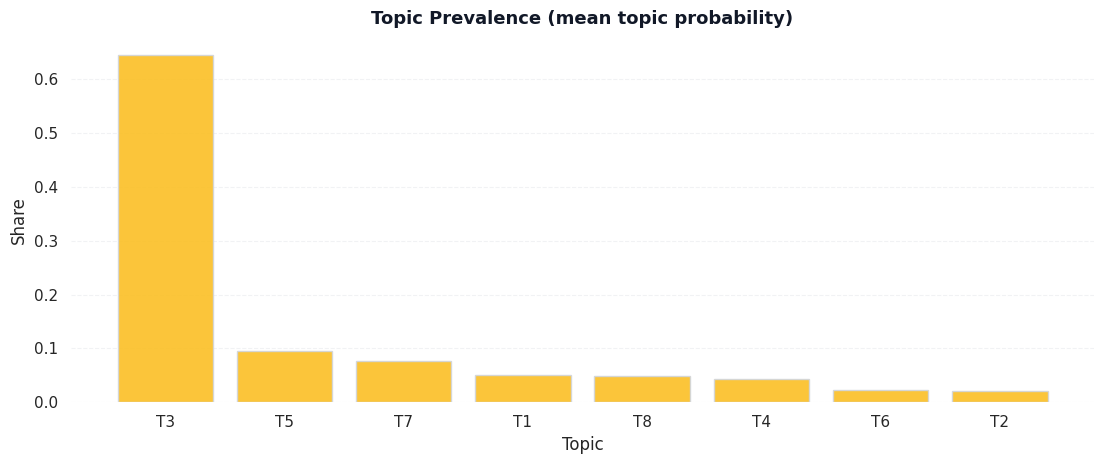

In [19]:
from sklearn.decomposition import LatentDirichletAllocation

# Guardrails
if "text_review" not in df_model.columns:
    raise KeyError("df_model must contain 'text_review' for VoC topic modeling.")

if "Xvoc" not in globals() or "cvect" not in globals():
    from sklearn.feature_extraction.text import CountVectorizer
    VOC_TEXT = df_model["text_review"].fillna("")
    cvect = CountVectorizer(
        max_features=30000, ngram_range=(1, 2), min_df=3, stop_words="english"
    )
    Xvoc = cvect.fit_transform(VOC_TEXT)

terms = np.array(cvect.get_feature_names_out())

N_TOPICS = 8
lda = LatentDirichletAllocation(
    n_components=N_TOPICS, random_state=SEED, learning_method="batch"
)
topic_probs = lda.fit_transform(Xvoc)

def get_topics_table(model, terms, topn=12):
    rows = []
    for i, comp in enumerate(model.components_):
        top_idx = np.argsort(comp)[-topn:][::-1]
        rows.append(
            {"Topic": f"T{i+1}", "TopTerms": ", ".join(terms[top_idx])}
        )
    return pd.DataFrame(rows)

topic_df = get_topics_table(lda, terms, topn=14)

# Topic prevalence (how much each topic dominates across corpus)
topic_share = pd.DataFrame({
    "Topic": [f"T{i+1}" for i in range(N_TOPICS)],
    "Share": topic_probs.mean(axis=0)
}).sort_values("Share", ascending=False).reset_index(drop=True)

df_tabs(
    [
        ("Topics — Top Terms", topic_df, 0, 50),
        ("Topic Prevalence", topic_share, 6, 50),
    ],
    panel_title="VoC Topic Discovery (LDA)"
)

# Optional: prevalence chart
fig, ax = plt.subplots(figsize=(11.2, 4.8))
hatch_panel(ax, alpha=0.05)

ax.bar(
    topic_share["Topic"],
    topic_share["Share"],
    edgecolor=THEME["grid"],
    alpha=0.9,
    color=THEME["yellow"],      
)

ax_title(ax, "Topic Prevalence (mean topic probability)")
ax.set_xlabel("Topic")
ax.set_ylabel("Share")
faint_dashed_ygrid(ax)
remove_spines(ax)
plt.tight_layout()
plt.show()

## 8.3 Category × Topic Coverage (operational hotspots)

,cat_l1,topic_id,rows,cat_rows,share_in_cat,at_risk_rate,avg_rating,excess_risk,hotspot_score
0,Home&Kitchen,3,400,423,95%,30.2%,4.07,6.8%,25.5771
1,Electronics,3,321,514,62%,33.3%,4.04,9.8%,19.7367
2,Car&Motorbike,3,1,1,100%,100.0%,3.80,76.5%,0.7651
3,MusicalInstruments,3,2,2,100%,50.0%,3.90,26.5%,0.5302
4,Home&Kitchen,7,22,423,5%,36.4%,3.98,12.9%,0.1473
5,Computers&Accessories,2,17,447,4%,29.4%,4.13,5.9%,0.0383
6,Computers&Accessories,3,260,447,58%,19.6%,4.15,0.0%,0.0000
7,Computers&Accessories,5,89,447,20%,13.5%,4.14,0.0%,0.0000
8,Electronics,1,63,514,12%,12.7%,4.11,0.0%,0.0000
9,Electronics,8,41,514,8%,12.2%,4.17,0.0%,0.0000


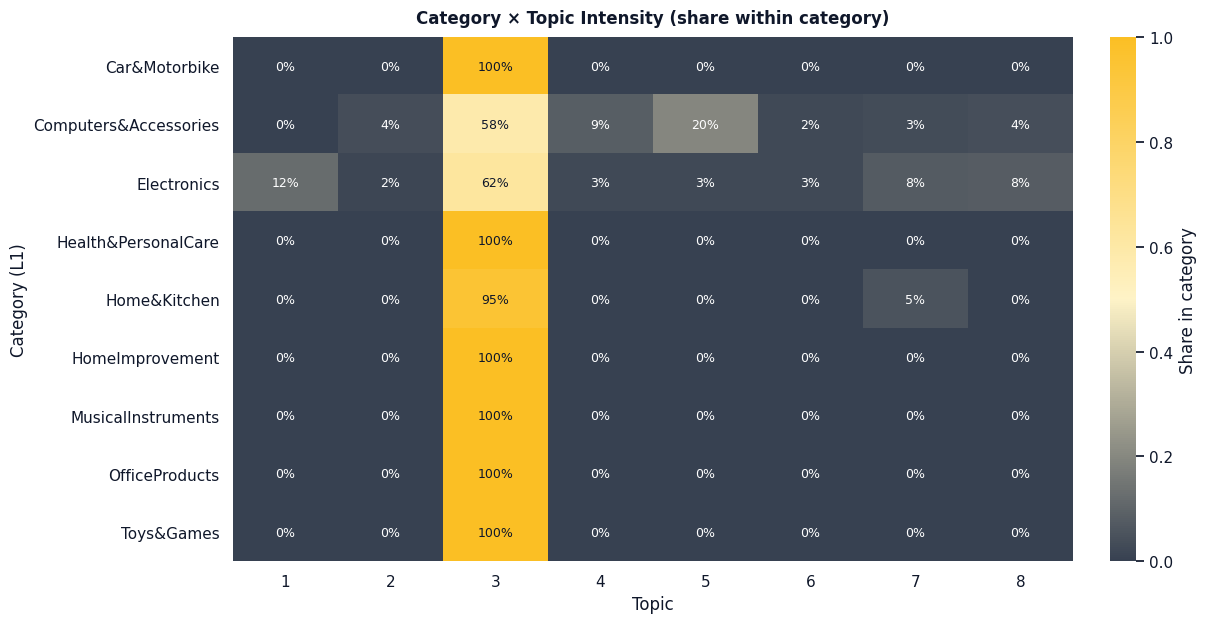

In [20]:
if "topic_probs" not in globals():
    raise NameError("topic_probs not found. Run topic modeling step to create topic_probs first.")

topic_probs_arr = np.asarray(topic_probs)
if topic_probs_arr.ndim != 2:
    raise ValueError(f"topic_probs must be 2D (n_rows x n_topics). Got shape={topic_probs_arr.shape}")

n_probs = int(topic_probs_arr.shape[0])
n_df = int(df_model.shape[0])
n = min(n_probs, n_df)

if n_probs != n_df:
    print(f"⚠️ topic_probs rows ({n_probs}) != df_model rows ({n_df}). Aligning to first {n} rows.")
    df_voc = df_model.iloc[:n].copy()
    topic_probs_arr = topic_probs_arr[:n, :]
else:
    df_voc = df_model.copy()

n_topics = int(topic_probs_arr.shape[1])

if "cat_l1" not in df_voc.columns:
    if "category" in df_voc.columns:
        df_voc["cat_l1"] = (
            df_voc["category"].fillna("").astype(str)
                 .str.split("|", n=1).str[0]
                 .replace("", np.nan)
        )
    else:
        df_voc["cat_l1"] = np.nan
df_voc["cat_l1"] = df_voc["cat_l1"].fillna("Unknown").astype(str)

df_voc["topic_id"] = (topic_probs_arr.argmax(axis=1) + 1).astype(int)

cat_topic = (
    df_voc.groupby(["cat_l1", "topic_id"], dropna=False)
          .size()
          .reset_index(name="rows")
)

cat_tot = (
    df_voc.groupby("cat_l1", dropna=False)
          .size()
          .reset_index(name="cat_rows")
)

cat_topic = cat_topic.merge(cat_tot, on="cat_l1", how="left")
cat_topic["share_in_cat"] = (
    (cat_topic["rows"] / cat_topic["cat_rows"])
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0.0)
)

if "at_risk" in df_voc.columns:
    df_voc["at_risk"] = pd.to_numeric(df_voc["at_risk"], errors="coerce").fillna(0).astype(int)
    if "rating" in df_voc.columns:
        df_voc["rating"] = pd.to_numeric(df_voc["rating"], errors="coerce")

    risk_sig = (
        df_voc.groupby(["cat_l1", "topic_id"], dropna=False)
              .agg(
                  at_risk_rate=("at_risk", "mean"),
                  avg_rating=("rating", "mean") if "rating" in df_voc.columns else ("at_risk", "mean"),
              )
              .reset_index()
    )
    cat_topic = cat_topic.merge(risk_sig, on=["cat_l1", "topic_id"], how="left")
else:
    cat_topic["at_risk_rate"] = np.nan
    cat_topic["avg_rating"] = np.nan

base_risk = float(pd.to_numeric(df_voc["at_risk"], errors="coerce").mean()) if "at_risk" in df_voc.columns else 0.0
cat_topic["excess_risk"] = (cat_topic["at_risk_rate"].fillna(0.0) - base_risk).clip(lower=0.0)

cat_topic["hotspot_score"] = (
    cat_topic["rows"].astype(float)
    * cat_topic["share_in_cat"].astype(float)
    * cat_topic["excess_risk"].astype(float)
)

hotspots = (
    cat_topic.sort_values(["hotspot_score", "rows", "share_in_cat"], ascending=False)
             .head(25)
             .reset_index(drop=True)
)

full_cov = (
    cat_topic.sort_values(["cat_l1", "topic_id"], ascending=[True, True])
             .reset_index(drop=True)
)

def fmt_int(x):
    if pd.isna(x): return "—"
    try: return f"{int(x):,}"
    except Exception: return str(x)

def fmt_pct(x, d=0):
    if pd.isna(x): return "—"
    try: return f"{100*float(x):.{d}f}%"
    except Exception: return str(x)

def fmt_float(x, d=4):
    if pd.isna(x): return "—"
    try: return f"{float(x):.{d}f}"
    except Exception: return str(x)

def fmt_rating(x):
    if pd.isna(x): return "—"
    try: return f"{float(x):.2f}"
    except Exception: return str(x)

hotspots_disp = hotspots.copy()
full_cov_disp = full_cov.copy()

for t in (hotspots_disp, full_cov_disp):
    if "rows" in t.columns: t["rows"] = t["rows"].map(fmt_int)
    if "cat_rows" in t.columns: t["cat_rows"] = t["cat_rows"].map(fmt_int)
    if "share_in_cat" in t.columns: t["share_in_cat"] = t["share_in_cat"].map(lambda v: fmt_pct(v, d=0))
    if "at_risk_rate" in t.columns: t["at_risk_rate"] = t["at_risk_rate"].map(lambda v: fmt_pct(v, d=1))
    if "excess_risk" in t.columns: t["excess_risk"] = t["excess_risk"].map(lambda v: fmt_pct(v, d=1))
    if "avg_rating" in t.columns: t["avg_rating"] = t["avg_rating"].map(fmt_rating)
    if "hotspot_score" in t.columns: t["hotspot_score"] = t["hotspot_score"].map(lambda v: fmt_float(v, d=4))

df_tabs(
    [
        ("Category × Topic (Top Hotspots)", hotspots_disp, 6, 50),
        ("Full Coverage (by Category)", full_cov_disp.head(120), 6, 120),
    ],
    panel_title="Operational Hotspots — Category × Topic"
)

try:
    from matplotlib.colors import LinearSegmentedColormap

    FG_DARK = "#0f172a"
    FG_LIGHT = "#ffffff"
    AX_BG = "white"
    FIG_BG = "white"

    if "YellowSlate" in globals():
        cmap = YellowSlate
    else:
        cmap = LinearSegmentedColormap.from_list(
            "YellowSlate_fallback",
            ["#f8fafc", "#e2e8f0", "#94a3b8", "#64748B", "#FBBF24"]
        )

    top_cats = df_voc["cat_l1"].value_counts(dropna=False).head(12).index.tolist()

    heat_counts = (
        df_voc[df_voc["cat_l1"].isin(top_cats)]
        .groupby(["cat_l1", "topic_id"])
        .size()
        .unstack(fill_value=0)
    )

    n_topics = int(np.max(df_voc["topic_id"])) if "topic_id" in df_voc.columns else heat_counts.shape[1]
    all_topics = list(range(1, n_topics + 1))
    heat_counts = heat_counts.reindex(columns=all_topics, fill_value=0).sort_index()

    heat_share = heat_counts.div(heat_counts.sum(axis=1), axis=0).fillna(0.0)

    fig, ax = plt.subplots(figsize=(12.2, 6.4))
    fig.patch.set_facecolor(FIG_BG)
    ax.set_facecolor(AX_BG)

    im = ax.imshow(
        heat_share.values,
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        vmin=0.0,
        vmax=1.0
    )

    ax.set_xticks(np.arange(len(heat_share.columns)))
    ax.set_yticks(np.arange(len(heat_share.index)))
    ax.set_xticklabels(heat_share.columns, color=FG_DARK)
    ax.set_yticklabels(heat_share.index, color=FG_DARK)
    ax.tick_params(colors=FG_DARK)
    ax.grid(False)

    THRESH = 0.35
    for i in range(heat_share.shape[0]):
        for j in range(heat_share.shape[1]):
            v = float(heat_share.iat[i, j])
            label_color = FG_LIGHT if v < THRESH else FG_DARK
            ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=9, color=label_color)

    ax.set_title("Category × Topic Intensity (share within category)", color=FG_DARK, pad=10, fontweight="bold")
    ax.set_xlabel("Topic", color=FG_DARK)
    ax.set_ylabel("Category (L1)", color=FG_DARK)

    for spine in ax.spines.values():
        spine.set_visible(False)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Share in category", color=FG_DARK)
    cbar.ax.yaxis.set_tick_params(color=FG_DARK)
    plt.setp(cbar.ax.get_yticklabels(), color=FG_DARK)
    cbar.outline.set_visible(False)
    cbar.ax.set_facecolor(FIG_BG)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Heatmap skipped:", e)

# 9. 🧩 RECOMMENDER — CONTENT-BASED PRODUCT DISCOVERY

## 9.1 Product Catalog Build (unique product_id aggregation)

In [21]:
# Guardrails
req = ["product_id", "product_name", "category", "about_product"]
missing = [c for c in req if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns in df for recommender: {missing}")

df_rec = df.copy()

# Build listing text for discovery (pre-purchase signal)
df_rec["product_text"] = (
    safe_text_col(df_rec, "product_name") + " " +
    safe_text_col(df_rec, "about_product") + " " +
    safe_text_col(df_rec, "category")
).str.strip()

# Aggregate to unique product_id to avoid duplicates
agg_dict = {
    "product_name": "first",
    "category": "first",
    "about_product": "first",
    "product_text": "first",
}

# Optional signals if exist
if "rating" in df_rec.columns:
    agg_dict["rating"] = "mean"
if "rating_count" in df_rec.columns:
    agg_dict["rating_count"] = "max"   # keep numeric, but we'll govern after agg
if "discounted_price" in df_rec.columns:
    agg_dict["discounted_price"] = "median"
if "actual_price" in df_rec.columns:
    agg_dict["actual_price"] = "median"
if "discount_percentage" in df_rec.columns:
    agg_dict["discount_percentage"] = "median"

df_catalog = (
    df_rec.dropna(subset=["product_id"])
          .groupby("product_id", as_index=False)
          .agg(agg_dict)
)

# GOVERNED TYPES + DISPLAY 
def _to_int64_nullable(s: pd.Series) -> pd.Series:
    # keeps NA as <NA>, prevents float display like 8131.000
    return pd.to_numeric(s, errors="coerce").round(0).astype("Int64")

def _fmt_count(x):
    if pd.isna(x):
        return "—"
    x = int(x)
    return f"{x:,}"  

def _fmt_rating(x):
    if pd.isna(x):
        return "—"
    return f"{float(x):.1f}"

def _fmt_pct(x):
    if pd.isna(x):
        return "—"
    return f"{float(x):.0f}%"  

def _fmt_inr(x):
    if pd.isna(x):
        return "—"
    try:
        return "₹{:,.0f}".format(float(x))
    except Exception:
        return str(x)

# rating -> display 
if "rating" in df_catalog.columns:
    df_catalog["rating"] = pd.to_numeric(df_catalog["rating"], errors="coerce")
    df_catalog["rating_display"] = df_catalog["rating"].map(_fmt_rating)

# rating_count -> Int64 + display 
if "rating_count" in df_catalog.columns:
    df_catalog["rating_count"] = _to_int64_nullable(df_catalog["rating_count"])
    df_catalog["rating_count_display"] = df_catalog["rating_count"].map(_fmt_count)

# prices -> display (already string, safe)
for c in ["discounted_price", "actual_price"]:
    if c in df_catalog.columns:
        df_catalog[f"{c}_display"] = pd.to_numeric(df_catalog[c], errors="coerce").map(_fmt_inr)

# discount_percentage -> display
if "discount_percentage" in df_catalog.columns:
    df_catalog["discount_percentage"] = pd.to_numeric(df_catalog["discount_percentage"], errors="coerce")
    df_catalog["discount_percentage_display"] = df_catalog["discount_percentage"].map(_fmt_pct)

# Readability helpers 
def truncate_series(s: pd.Series, n: int = 180) -> pd.Series:
    s = s.fillna("").astype(str)
    return s.str.slice(0, n) + np.where(s.str.len() > n, "…", "")

# Preview tables (Pricing vs Text)
pricing_cols = [
    "product_id",
    "product_name",
    "discounted_price_display",
    "actual_price_display",
    "discount_percentage_display",
    "rating_display",
    "rating_count_display",
    "category",
]
pricing_cols = [c for c in pricing_cols if c in df_catalog.columns]
df_pricing = df_catalog[pricing_cols].copy()

text_cols = ["product_id", "product_name", "about_product", "product_text"]
text_cols = [c for c in text_cols if c in df_catalog.columns]
df_text = df_catalog[text_cols].copy()

for c in ["about_product", "product_text"]:
    if c in df_text.columns:
        df_text[c] = truncate_series(df_text[c], n=220)

# CSS 
display(HTML("""
<style>
.df-scroll { overflow-x:auto; border-radius:14px; border:1px solid rgba(55,65,81,0.18); }
.df-scroll .dataframe { width:100%; border-collapse:collapse; font-size:12.5px; line-height:1.35; }
.df-scroll .dataframe th, .df-scroll .dataframe td {
  padding:8px 10px !important; border-bottom:1px solid rgba(55,65,81,0.10);
  vertical-align:top; white-space:nowrap;
}
.df-scroll .dataframe thead th {
  position:sticky; top:0; background:#fff; z-index:2; border-bottom:1px solid rgba(55,65,81,0.18);
}
/* Make product_name + category more compact (ellipsis) */
.df-scroll .dataframe td:nth-child(2) { max-width:320px; overflow:hidden; text-overflow:ellipsis; }
.df-scroll .dataframe td:last-child { max-width:260px; overflow:hidden; text-overflow:ellipsis; }
/* Give numeric columns more room */
.df-scroll .dataframe td:nth-child(3),
.df-scroll .dataframe td:nth-child(4),
.df-scroll .dataframe td:nth-child(5),
.df-scroll .dataframe td:nth-child(6),
.df-scroll .dataframe td:nth-child(7) { min-width:110px; }
</style>
"""))

# KPI cards
kpi_cards([
    {"title": "Catalog Rows (unique products)", "value": f"{df_catalog.shape[0]:,}", "accent": THEME["slate"]},
    {"title": "Original Rows (listings)", "value": f"{df.shape[0]:,}", "accent": THEME["yellow"]},
    {"title": "Text Field", "value": "product_text (listing)", "accent": THEME["muted"]},
])

# Tabs
df_tabs(
    [
        ("Pricing Snapshot", df_pricing.head(12), 3, 12),
        ("Text Signals (Preview)", df_text.head(8), 3, 8),
    ],
    panel_title="Product Catalog (Unique product_id)"
)

,product_id,product_name,discounted_price_display,actual_price_display,discount_percentage_display,rating_display,rating_count_display,category
0,B002PD61Y4,D-Link DWA-131 300 Mbps Wireless Nano USB Adapter (Black),₹507,"₹1,208",58%,4.1,"8,131",Computers&Accessories|NetworkingDevices|NetworkAdapters|WirelessUSBAdapters
1,B002SZEOLG,"TP-Link Nano USB WiFi Dongle 150Mbps High Gain Wireless Network Wi-Fi Adapter for PC Desktop and Laptops, Supports Windows 10/8.1/8/7/XP, Linux, Mac OS X (TL-WN722N)",₹749,"₹1,339",44%,4.2,"179,692",Computers&Accessories|NetworkingDevices|NetworkAdapters|WirelessUSBAdapters
2,B003B00484,Duracell Plus AAA Rechargeable Batteries (750 mAh) Pack of 4,₹399,₹499,20%,4.3,"27,201",Electronics|GeneralPurposeBatteries&BatteryChargers|RechargeableBatteries
3,B003L62T7W,"Logitech B100 Wired USB Mouse, 3 yr Warranty, 800 DPI Optical Tracking, Ambidextrous PC/Mac/Laptop - Black",₹279,₹375,26%,4.3,"31,534","Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Mice"
4,B004IO5BMQ,"Logitech M235 Wireless Mouse, 1000 DPI Optical Tracking, 12 Month Life Battery, Compatible with Windows, Mac, Chromebook/PC/Laptop",₹699,₹995,30%,4.5,"54,405","Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Mice"
5,B005FYNT3G,SanDisk Cruzer Blade 32GB USB Flash Drive,₹289,₹650,56%,4.3,"253,105",Computers&Accessories|ExternalDevices&DataStorage|PenDrives
6,B005LJQMCK,"BlueRigger Digital Optical Audio Toslink Cable (3.3 Feet / 1 Meter) With 8 Channel (7.1) Audio Support (for Home Theatre, Xbox, Playstation etc.)",₹416,₹599,31%,4.2,"30,023","Electronics|HomeTheater,TV&Video|Accessories|Cables|OpticalCables"
7,B005LJQMZC,"BlueRigger Digital Optical Audio Toslink Cable (6 Feet / 1.8 Meter) With 8 Channel (7.1) Audio Support (for Home Theatre, Xbox, Playstation etc.)",₹486,"₹1,999",76%,4.2,"30,023","Electronics|HomeTheater,TV&Video|Accessories|Cables|OpticalCables"
8,B006LW0WDQ,Amazon Basics 16-Gauge Speaker Wire - 50 Feet,₹399,₹795,50%,4.4,"12,091","Electronics|HomeTheater,TV&Video|Accessories|Cables|SpeakerCables"
9,B0073QGKAS,Bajaj ATX 4 750-Watt Pop-up Toaster (White),"₹1,499","₹1,499",0%,4.3,"9,331",Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|Pop-upToasters


## 9.2 TF-IDF Similarity (top-N “more like this”) — scalable (no full NxN matrix)

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

vec = TfidfVectorizer(
    max_features=60000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words="english",
    dtype=np.float32,
)

M = vec.fit_transform(df_catalog["product_text"].fillna(""))

M_norm = normalize(M, norm="l2", axis=1, copy=False)

pid_to_idx = pd.Series(df_catalog.index, index=df_catalog["product_id"].astype(str))

## 9.3 Search + Recommendation Demo (lightweight, explainable)

In [23]:
def recommend_by_product_id(product_id, top_n=8):
    pid = str(product_id).strip()
    if pid not in pid_to_idx.index:
        return pd.DataFrame({"note": [f"product_id not found: {pid}"]})

    i = int(pid_to_idx.loc[pid])

    scores = (M_norm @ M_norm[i].T).toarray().ravel()
    top_idx = np.argsort(scores)[::-1]
    top_idx = [j for j in top_idx if j != i][:top_n]

    cols = ["product_id", "product_name", "category"]

    if "rating_display" in df_catalog.columns:
        cols.append("rating_display")
    elif "rating" in df_catalog.columns:
        cols.append("rating")

    for c in ["discounted_price_display", "actual_price_display"]:
        if c in df_catalog.columns:
            cols.append(c)

    if "rating_count_display" in df_catalog.columns:
        cols.append("rating_count_display")
    elif "rating_count" in df_catalog.columns:
        cols.append("rating_count")  # fallback

    if "discount_percentage_display" in df_catalog.columns:
        cols.append("discount_percentage_display")
    elif "discount_percentage" in df_catalog.columns:
        cols.append("discount_percentage")  # fallback

    out = df_catalog.loc[top_idx, cols].copy()

    out["similarity"] = scores[top_idx]
    out["similarity_display"] = out["similarity"].map(lambda v: f"{v:.4f}")

    return out.reset_index(drop=True)

def search_products(keyword, top_n=10):
    kw = str(keyword).lower().strip()
    mask = df_catalog["product_text"].fillna("").str.lower().str.contains(kw, na=False)

    cols = ["product_id", "product_name", "category"]

    if "rating_display" in df_catalog.columns:
        cols.append("rating_display")
    elif "rating" in df_catalog.columns:
        cols.append("rating")

    for c in ["discounted_price_display", "actual_price_display"]:
        if c in df_catalog.columns:
            cols.append(c)

    if "rating_count_display" in df_catalog.columns:
        cols.append("rating_count_display")
    elif "rating_count" in df_catalog.columns:
        cols.append("rating_count")

    if "discount_percentage_display" in df_catalog.columns:
        cols.append("discount_percentage_display")
    elif "discount_percentage" in df_catalog.columns:
        cols.append("discount_percentage")

    return df_catalog.loc[mask, cols].head(top_n).reset_index(drop=True)

demo_pid = str(df_catalog["product_id"].iloc[0])
rec_df = recommend_by_product_id(demo_pid, top_n=8)

catalog_head_cols = [
    "product_id", "product_name", "category",
    "discounted_price_display", "actual_price_display",
    "discount_percentage_display", "rating_display", "rating_count_display"
]
catalog_head_cols = [c for c in catalog_head_cols if c in df_catalog.columns]
catalog_head = df_catalog[catalog_head_cols].head(8).copy() if catalog_head_cols else df_catalog.head(8)

df_tabs(
    [
        ("Recommendations (Top-N)", rec_df, 4, 20),
        ("Search: 'cable' (sample)", search_products("cable", top_n=10), 3, 20),
        ("Catalog Sample (Head)", catalog_head, 3, 8),
    ],
    panel_title="Recommender Demo — Content-Based (TF-IDF Similarity)"
)

print("Demo product_id:", demo_pid)

Demo product_id: B002PD61Y4


# 10. 🚀 EXECUTIVE SUMMARY & NEXT STEPS

## 10.1 What was validated (types, integrity, category signal)

In [24]:
def fmt_pct_1(x):
    if pd.isna(x):
        return "—"
    return f"{100*float(x):.1f}%"

def fmt_rate_1(x):
    return fmt_pct_1(x)

def fmt_int(x):
    if pd.isna(x):
        return "—"
    try:
        return f"{int(x):,}"
    except Exception:
        return str(x)

def fmt_float_2(x):
    if pd.isna(x):
        return "—"
    return f"{float(x):.2f}"

def fmt_pp_1(x):
    if pd.isna(x):
        return "—"
    return f"{float(x):.1f} pp"

validated = pd.DataFrame([{
    "Rows": int(df.shape[0]),
    "UniqueProducts": int(df["product_id"].nunique()) if "product_id" in df.columns else np.nan,
    "ActualPrice_NonNull_%": float(df["actual_price"].notna().mean()) if "actual_price" in df.columns else np.nan,
    "DiscountedPrice_NonNull_%": float(df["discounted_price"].notna().mean()) if "discounted_price" in df.columns else np.nan,
    "DiscountPP_NonNull_%": float(df["discount_percentage"].notna().mean()) if "discount_percentage" in df.columns else np.nan,
    "Rating_NonNull_%": float(df["rating"].notna().mean()) if "rating" in df.columns else np.nan,
    "Votes_NonNull_%": float(df["rating_count"].notna().mean()) if "rating_count" in df.columns else np.nan,
    "DiscountInconsistencyRate_defect>3pp": float(df["discount_inconsistency_flag"].mean()) if "discount_inconsistency_flag" in df.columns else np.nan,
    "MultiUserRowRate": float(df["multi_user_flag"].mean()) if "multi_user_flag" in df.columns else np.nan,
    "L1_Unique": int(df["cat_l1"].nunique(dropna=True)) if "cat_l1" in df.columns else np.nan,
}])

validated_display = validated.copy()

for c in ["Rows", "UniqueProducts", "L1_Unique"]:
    if c in validated_display.columns:
        validated_display[c] = validated_display[c].map(fmt_int)

for c in [
    "ActualPrice_NonNull_%", "DiscountedPrice_NonNull_%", "DiscountPP_NonNull_%",
    "Rating_NonNull_%", "Votes_NonNull_%"
]:
    if c in validated_display.columns:
        validated_display[c] = validated_display[c].map(fmt_pct_1)

for c in ["DiscountInconsistencyRate_defect>3pp", "MultiUserRowRate"]:
    if c in validated_display.columns:
        validated_display[c] = validated_display[c].map(fmt_rate_1)

if "discount_percentage" in df.columns:
    disc = pd.to_numeric(df["discount_percentage"], errors="coerce").dropna()
    if len(disc) > 0:
        disc_profile = pd.DataFrame([{
            "discount_pp_p50": float(np.nanpercentile(disc, 50)),
            "discount_pp_p90": float(np.nanpercentile(disc, 90)),
            "discount_pp_p95": float(np.nanpercentile(disc, 95)),
            "discount_pp_max": float(np.nanmax(disc)),
        }])
    else:
        disc_profile = pd.DataFrame([{
            "discount_pp_p50": np.nan, "discount_pp_p90": np.nan,
            "discount_pp_p95": np.nan, "discount_pp_max": np.nan
        }])
else:
    disc_profile = pd.DataFrame([{
        "discount_pp_p50": np.nan, "discount_pp_p90": np.nan,
        "discount_pp_p95": np.nan, "discount_pp_max": np.nan
    }])

disc_profile_display = disc_profile.copy()
for c in disc_profile_display.columns:
    disc_profile_display[c] = disc_profile_display[c].map(fmt_pp_1)

df_tabs(
    [
        ("Validated Signals", validated_display, 4, 10),
        ("Discount Scale Profile", disc_profile_display, 4, 10),
    ],
    panel_title="Executive Validation — Types, Integrity, Taxonomy"
)

## 10.2 What was learned (risk drivers, VoC themes, discovery patterns)

In [25]:
def fmt_pct_1(x):
    if pd.isna(x):
        return "—"
    return f"{100*float(x):.1f}%"

def fmt_num_1(x):
    if pd.isna(x):
        return "—"
    return f"{float(x):.1f}"

def fmt_int(x):
    if pd.isna(x):
        return "—"
    try:
        return f"{int(x):,}"
    except Exception:
        return str(x)

if "at_risk" in df_model.columns and "cat_l1" in df_model.columns:
    risk_by_cat = (
        df_model.groupby("cat_l1", dropna=False)
                .agg(
                    rows=("product_id","size") if "product_id" in df_model.columns else ("rating","size"),
                    at_risk_rate=("at_risk","mean"),
                    avg_rating=("rating","mean")
                )
                .reset_index()
                .sort_values(["at_risk_rate", "rows"], ascending=False)
                .head(15)
    )

    risk_by_cat["rows_display"] = risk_by_cat["rows"].map(fmt_int)
    risk_by_cat["at_risk_rate_display"] = risk_by_cat["at_risk_rate"].map(fmt_pct_1)
    risk_by_cat["avg_rating_display"] = risk_by_cat["avg_rating"].map(fmt_num_1)

    risk_by_cat = risk_by_cat[[
        "cat_l1", "rows_display", "at_risk_rate_display", "avg_rating_display"
    ]].rename(columns={
        "cat_l1": "Category (L1)",
        "rows_display": "Rows",
        "at_risk_rate_display": "At-Risk Rate",
        "avg_rating_display": "Avg Rating"
    })
else:
    risk_by_cat = pd.DataFrame({"note": ["cat_l1/at_risk not available for risk summary."]})

# ---------- VoC tables (no change unless you want) ----------
top_topics = topic_share.head(6).copy() if "topic_share" in globals() else pd.DataFrame({"note": ["topic_share not available."]})
top_hotspots = hotspots.head(12).copy() if "hotspots" in globals() else pd.DataFrame({"note": ["hotspots not available. Run 8.3 first."]})

for col in ["share_in_cat", "at_risk_rate", "excess_risk"]:
    if col in top_hotspots.columns:
        top_hotspots[f"{col}_display"] = top_hotspots[col].map(fmt_pct_1)

# ---------- Recommender readiness KPIs ----------
catalog_kpi = pd.DataFrame([{
    "CatalogRows": int(df_catalog.shape[0]) if "df_catalog" in globals() else np.nan,
    "HasRating_%": float(df_catalog["rating"].notna().mean()) if "df_catalog" in globals() and "rating" in df_catalog.columns else np.nan,
    "HasPrice_%": float(df_catalog["discounted_price"].notna().mean()) if "df_catalog" in globals() and "discounted_price" in df_catalog.columns else np.nan,
    "VectorVocabSize": int(len(vec.vocabulary_)) if "vec" in globals() else np.nan,
}])

catalog_kpi_display = catalog_kpi.copy()
if "CatalogRows" in catalog_kpi_display.columns:
    catalog_kpi_display["CatalogRows"] = catalog_kpi_display["CatalogRows"].map(fmt_int)
if "VectorVocabSize" in catalog_kpi_display.columns:
    catalog_kpi_display["VectorVocabSize"] = catalog_kpi_display["VectorVocabSize"].map(fmt_int)
for c in ["HasRating_%", "HasPrice_%"]:
    if c in catalog_kpi_display.columns:
        catalog_kpi_display[c] = catalog_kpi_display[c].map(fmt_pct_1)

df_tabs(
    [
        ("Risk — Top Categories", risk_by_cat, 4, 50),
        ("VoC — Top Topics", top_topics, 6, 20),
        ("VoC — Hotspots (Cat × Topic)", top_hotspots, 4, 50),
        ("Discovery — Recommender Readiness", catalog_kpi_display, 4, 10),
    ],
    panel_title="Executive Learnings — Risk, VoC, Discovery"
)

## 10.3 Enhancements (evaluation, offline metrics, cold-start, ranking)

- **RecSys evaluation:** Define offline metrics (**MAP@K**, **NDCG@K**) and a holdout protocol (time-based if possible).
- **Cold-start strategy:** Enrich `product_text` with structured attributes (brand, specs) + category priors.
- **Ranking layer:** Replace pure similarity with a learning-to-rank or a re-ranker using engagement proxies.
- **Quality loop:** Route high `hotspot_score` (Cat×Topic) cohorts into QA, pricing audit, and content fixes.
- **Monitoring:** Track discount drift (soft/hard) and topic mix shifts per category over time.

## Executive Close

This notebook converts raw marketplace data into a governed, decision-grade asset. Prices and discounts are typed and validated, category segmentation is made dashboard-ready through a shallow taxonomy, and integrity diagnostics confirm that discount differences are mostly small (**Mean |pp diff| = 0.209; P95 = 0.472**) with no hard mismatches (**> 1pp**). On top of this trusted foundation, a **PR-AUC-first** satisfaction-risk model detects underperformance risk (champion: **Uplift TextAllClean**, Test **PR-AUC = 0.723**, **ROC-AUC = 0.888**), while **VoC topic modeling** and a **TF-IDF** content-based recommender provide an activation layer for discovery and prioritization. The result is a single end-to-end workflow that operationalizes **Governance**, **Risk**, and **RecSys** into an executive-readable analytics product.


<div style="
  background: linear-gradient(90deg,#fff7ed 0%, #fffbeb 40%, #f1f5f9 100%);
  padding: 20px 22px;
  border-radius: 12px;
  color: #0f172a;
  font-size: 16px;
  line-height: 1.7;
  box-shadow: 0 4px 18px rgba(15,23,42,0.12);
  margin-top: 30px;
  border: 1px solid rgba(251,191,36,0.45);
">

  <h1 style="color:#111827; margin: 0 0 10px 0; font-weight: 900;">
    🛒 Support & Feedback — Amazon Governance × Risk × Discovery
  </h1>

  <p style="margin: 10px 0 12px 0; color: rgba(15,23,42,0.88);">
    If this notebook helped you turn raw Amazon marketplace signals into <strong>decision-grade insights</strong>
    (typed INR pricing, discount integrity, category scorecards, satisfaction-risk modeling, and discovery baselines),
    you can support the work by:
  </p>

  <ul style="margin:8px 0 14px 18px; padding:0; color: rgba(15,23,42,0.88);">
    <li style="margin:6px 0;">⭐ <strong>Upvoting</strong> so it reaches more analysts and product teams</li>
    <li style="margin:6px 0;">💬 <strong>Commenting</strong> — governance edge-cases, modeling ideas, or metrics suggestions</li>
    <li style="margin:6px 0;">🔁 <strong>Forking</strong> to extend scorecards, add ranking, or productionize the RecSys baseline</li>
  </ul>

  <p style="margin: 0; color: rgba(15,23,42,0.82);">
    Your engagement helps keep open, governance-first analytics evolving — with outputs that stay
    <strong>comparable, explainable, and operationally actionable</strong>.
  </p>

  <blockquote style="
    background-color: rgba(251,191,36,0.12);
    border-left: 5px solid #f59e0b;
    padding: 12px 18px;
    margin: 18px 0 0 0;
    font-style: italic;
    color:#111827;">
    <em>Govern the signals, surface the risk, and activate discovery — fast, explainable, and decision-ready.</em>
  </blockquote>

</div>